# Análisis VARX-MGARCH: Índice ENSO 3.4 (RONI), Aportes Hídricos, Generación y Precio de Bolsa de Energía en Colombia

## Objetivo del proyecto

Este notebook desarrolla un análisis econométrico completo de series de tiempo con el fin de estudiar la
relación dinámica entre cuatro variables del mercado eléctrico colombiano:

1. **RONI** (Relative Oceanic Niño Index) de la región El Niño 3.4 — indicador del fenómeno ENSO (El Niño-Oscilación del Sur).
2. **Aportes hídricos** al sistema eléctrico (m³/s).
3. **Generación eléctrica** (kWh).
4. **Precio de bolsa de energía** (COP/kWh).

El fenómeno ENSO es reconocido en la literatura hidrológica y energética como uno de los principales
determinantes de la disponibilidad de agua en las cuencas que alimentan el parque de generación
hidroeléctrico colombiano (que históricamente representa cerca del 70% de la matriz energética del país).
En años Niño (fases cálidas, RONI > 0) se presentan históricamente déficits de precipitación que reducen los
aportes hídricos, obligan a mayor generación térmica (más costosa) y presionan al alza el precio de bolsa.
En años Niña (fases frías, RONI < 0) ocurre el patrón inverso.

**Pregunta de investigación:** ¿Existe evidencia econométrica robusta de que el índice RONI 3.4 antecede y
explica dinámicamente los movimientos en aportes hídricos, generación y precio de bolsa, y existe
suficiente estructura de volatilidad condicional (heterocedasticidad) como para sustentar el diseño de un
**derivado climático** (weather/climate derivative) que permita cubrir el riesgo de precio asociado a
eventos ENSO en el mercado eléctrico colombiano?

**Metodología:** se combina un modelo de Vectores Autorregresivos (VAR) — con el índice RONI incorporado
como variable clave del sistema dinámico — con un modelo Multivariado GARCH (aproximación CCC-GARCH) sobre
los residuales del VAR, para capturar tanto la dinámica de las medias condicionales (VAR) como la dinámica
de las varianzas y covarianzas condicionales (MGARCH). Esta combinación se conoce en la literatura como
**VAR(X)-MGARCH**.

**Nota metodológica sobre la naturaleza de RONI:** climatológicamente, RONI es una variable exógena al
mercado eléctrico colombiano (el mercado no afecta al océano Pacífico), lo cual motiva el nombre "VARX". Sin
embargo, para poder responder preguntas de causalidad de Granger bidireccional y construir funciones
impulso-respuesta completas entre las cuatro variables (tal como se solicita en este análisis), el índice se
incorpora **dentro del sistema VAR como una variable endógena adicional**. Esto es una práctica estándar en
la literatura aplicada (p. ej. estudios de VAR climático-económicos) y se documenta explícitamente en la
Sección 4. El resultado es un VAR de 4 variables cuya interpretación económica respeta la exogeneidad física
de RONI: se espera —y se verifica— que las demás variables no "causen" a RONI en el sentido de Granger.

## 1. Importación de librerías

Se importan únicamente las librerías efectivamente utilizadas a lo largo del notebook:

- **pandas / numpy**: manejo de datos y cálculo numérico.
- **matplotlib / seaborn**: visualización.
- **statsmodels**: pruebas de raíz unitaria (ADF, KPSS), estimación del modelo VAR, causalidad de Granger,
  funciones impulso-respuesta (IRF), descomposición de varianza (FEVD) y pronóstico.
- **scipy.stats**: pruebas estadísticas complementarias (Jarque-Bera, Shapiro-Wilk).
- **arch**: estimación de modelos GARCH univariados, utilizados como bloque de construcción del modelo
  MGARCH (enfoque de Correlación Condicional Constante, CCC-GARCH).

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import durbin_watson
from arch import arch_model
from arch.univariate.base import DataScaleWarning

warnings.filterwarnings("ignore", category=DataScaleWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12

RANDOM_STATE = 42
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga de datos

El archivo `data.csv` ya se encuentra consolidado y no requiere limpieza. Únicamente se realiza la lectura,
la conversión de la columna `date` a formato de fecha y su asignación como índice temporal con frecuencia
mensual explícita (`MS`, *month start*), lo cual es indispensable para que `statsmodels` reconozca
correctamente la periodicidad de la serie.

**Variables:**

| Variable | Columna en CSV | Descripción | Unidad |
|---|---|---|---|
| Índice ENSO | `RONI` | Relative Oceanic Niño Index, región Niño 3.4 | Anomalía de temperatura (°C) |
| Aportes hídricos | `APORTES` | Caudal medio afluente a embalses del SIN | m³/s |
| Precio de bolsa | `ENERGY_PRICE` | Precio de bolsa de energía eléctrica | COP/kWh |
| Generación | `GENERATION` | Generación eléctrica total del sistema | kWh |

In [3]:
df_raw = pd.read_csv("data/RONI_APORTES_PRICE_GENERATION_monthly_2000-2024.csv", parse_dates=["date"])
df_raw = df_raw.rename(
    columns={
        "RONI": "indice",
        "APORTES": "aportes",
        "ENERGY_PRICE": "precio",
        "GENERATION": "generacion",
    }
)
df_raw = df_raw.set_index("date").sort_index()
df_raw.index.freq = "MS"

df = df_raw[["indice", "aportes", "precio", "generacion"]].copy()

print(f"Rango temporal: {df.index.min().date()} a {df.index.max().date()}")
print(f"Número de observaciones mensuales: {len(df)}")
df.head()

Rango temporal: 2000-01-01 a 2024-12-01
Número de observaciones mensuales: 300


,indice,aportes,precio,generacion
date,,,,
2000-01-01,-1.79,1.055922e+08,36.778780,7.944395e+07
2000-02-01,-1.53,1.107575e+08,40.261477,7.146242e+07
2000-03-01,-1.26,1.251867e+08,37.637297,8.386839e+07
2000-04-01,-0.80,1.349806e+08,44.298057,7.508375e+07
2000-05-01,-0.80,2.676612e+08,37.291122,8.722126e+07


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
indice,300.0,-1.060000e-02,8.240095e-01,-1.790000e+00,-5.875000e-01,-8.500000e-02,4.800000e-01,2.570000e+00
aportes,300.0,1.641789e+08,6.458401e+07,4.677111e+07,1.133542e+08,1.642640e+08,2.056831e+08,3.907349e+08
precio,300.0,1.776336e+02,1.960929e+02,3.505497e+01,7.060601e+01,1.072208e+02,1.884221e+02,1.529134e+03
generacion,300.0,3.943166e+07,9.179821e+06,1.915901e+07,3.495211e+07,3.946171e+07,4.145178e+07,8.793532e+07


## 3. Visualización exploratoria

Antes de estimar cualquier modelo es indispensable comprender el comportamiento univariado y conjunto de las
series: su tendencia, posibles cambios de nivel, estacionalidad, atipicidad y volatilidad. Estos elementos
guían las decisiones metodológicas de las secciones siguientes (transformación, diferenciación, orden de
rezagos).

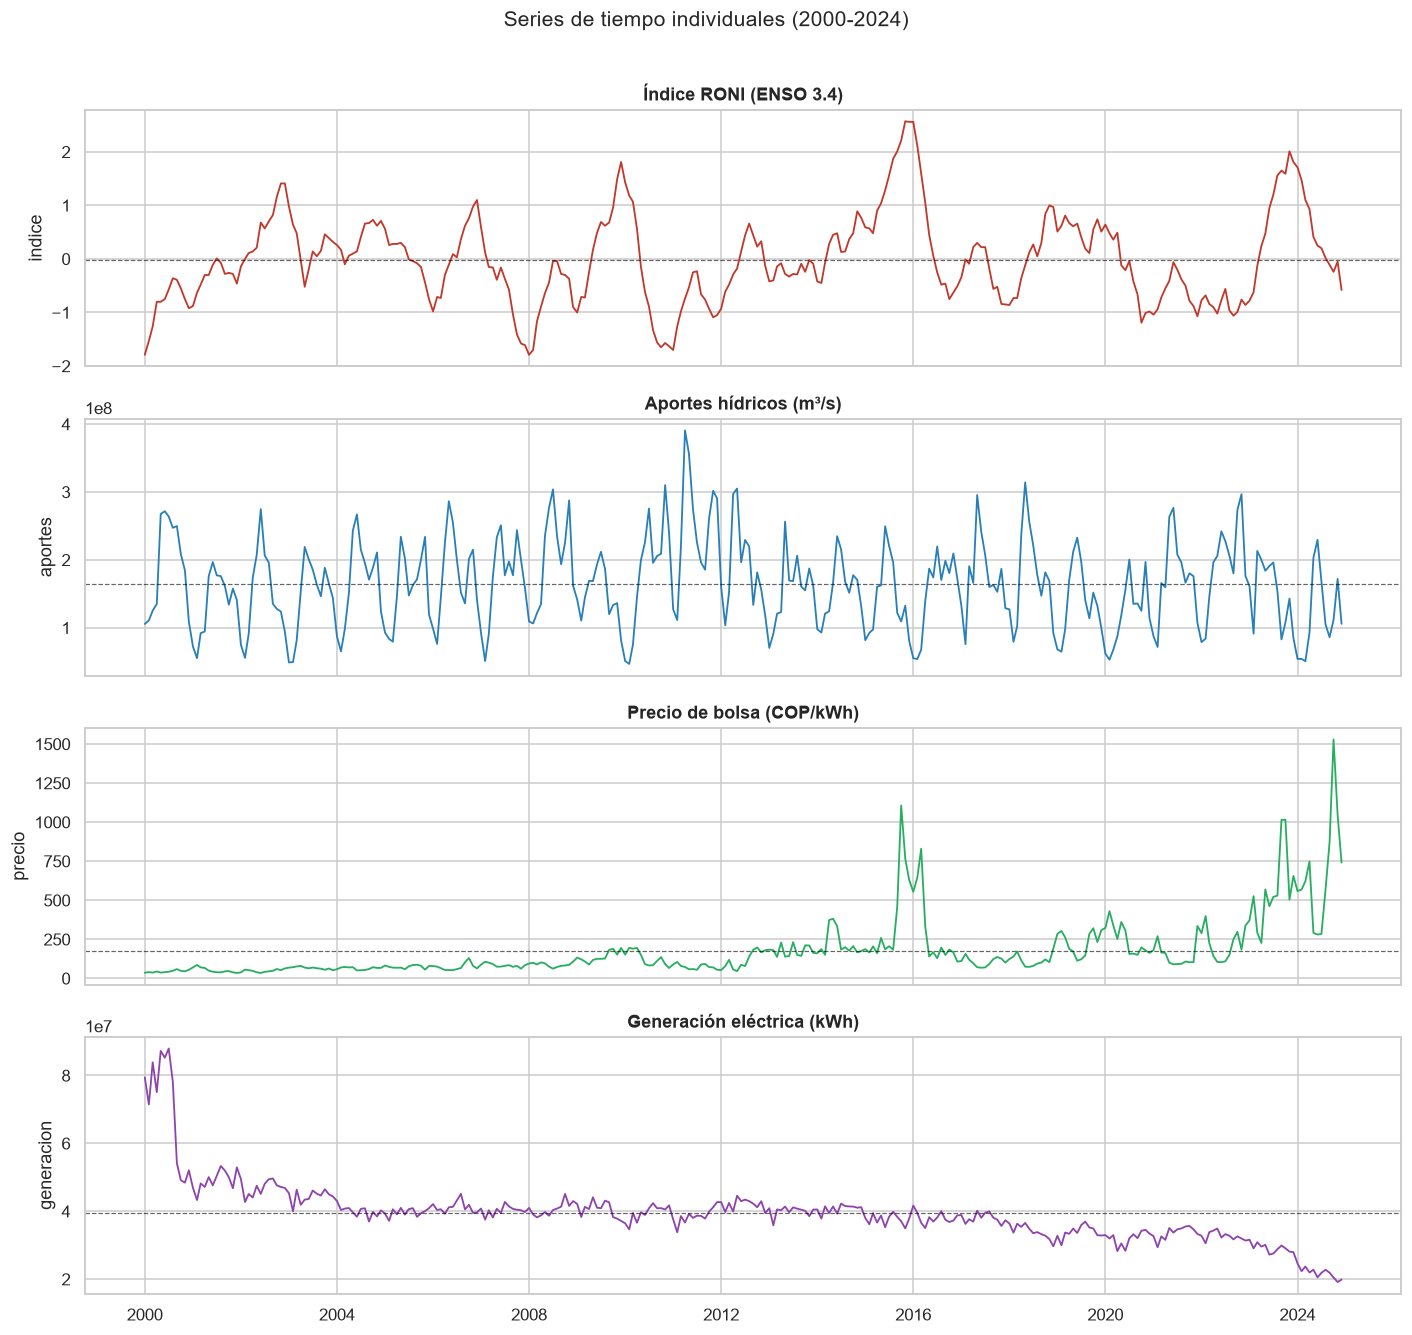

In [5]:
labels = {
    "indice": "Índice RONI (ENSO 3.4)",
    "aportes": "Aportes hídricos (m³/s)",
    "precio": "Precio de bolsa (COP/kWh)",
    "generacion": "Generación eléctrica (kWh)",
}
colors = {"indice": "#c0392b", "aportes": "#2980b9", "precio": "#27ae60", "generacion": "#8e44ad"}

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
for ax, col in zip(axes, df.columns):
    ax.plot(df.index, df[col], color=colors[col], linewidth=1.2)
    ax.axhline(df[col].mean(), color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_title(labels[col])
    ax.set_ylabel(col)
fig.suptitle("Series de tiempo individuales (2000-2024)", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()

**Interpretación:** el índice RONI oscila de forma cíclica e irregular entre valores negativos (fases La
Niña) y positivos (fases El Niño), sin tendencia de largo plazo, consistente con un fenómeno climático
oscilatorio de media reversión. Los aportes hídricos muestran estacionalidad marcada y caídas abruptas
coincidentes con los eventos El Niño más fuertes (2009-2010, 2015-2016, 2023-2024). El precio de bolsa
exhibe una tendencia creciente de largo plazo junto con picos extremos de volatilidad —particularmente en
2024, año de un evento El Niño fuerte—, sugiriendo la presencia de heterocedasticidad condicional. La
generación eléctrica presenta una tendencia estructural decreciente desde 2013-2014 aproximadamente, posible
reflejo de cambios en la composición de la matriz energética y en la medición del sistema, además de
estacionalidad.

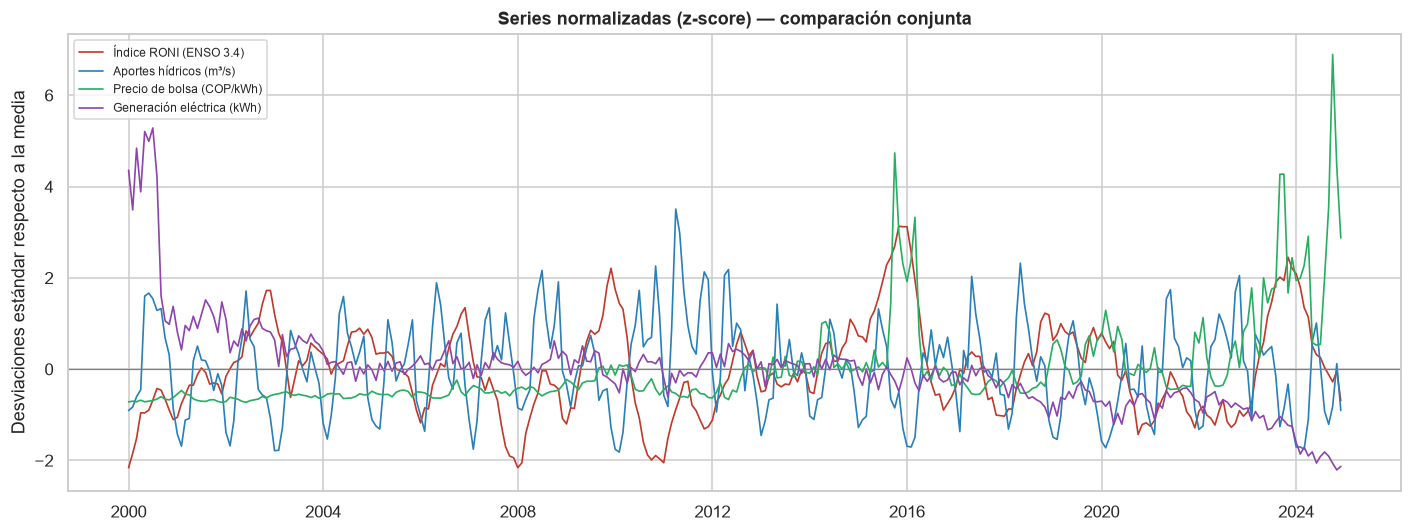

In [6]:
df_norm = (df - df.mean()) / df.std()

fig, ax = plt.subplots(figsize=(13, 5))
for col in df.columns:
    ax.plot(df_norm.index, df_norm[col], label=labels[col], color=colors[col], linewidth=1.1)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Series normalizadas (z-score) — comparación conjunta")
ax.set_ylabel("Desviaciones estándar respecto a la media")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

**Interpretación:** al normalizar las series se observa con mayor claridad la coincidencia temporal entre
picos positivos del índice RONI y caídas simultáneas en aportes hídricos, así como su relación con
repuntes posteriores del precio de bolsa — visible de forma particularmente nítida en los eventos de
2009-2010, 2015-2016 y 2023-2024. Esta coincidencia visual constituye la primera evidencia informal a favor
de una relación dinámica entre las variables, que se someterá a prueba formal en las secciones siguientes.

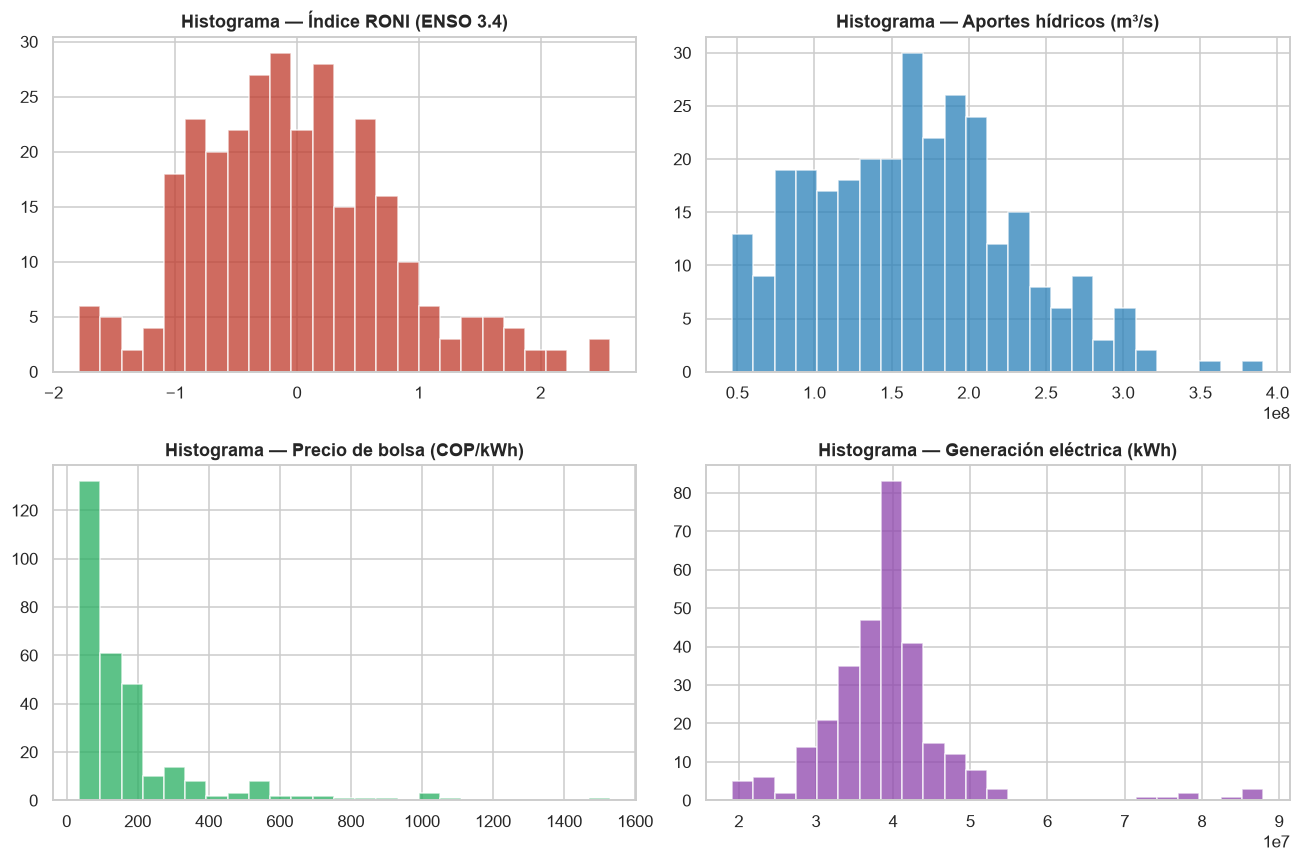

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), df.columns):
    ax.hist(df[col], bins=25, color=colors[col], alpha=0.75, edgecolor="white")
    ax.set_title(f"Histograma — {labels[col]}")
fig.tight_layout()
plt.show()

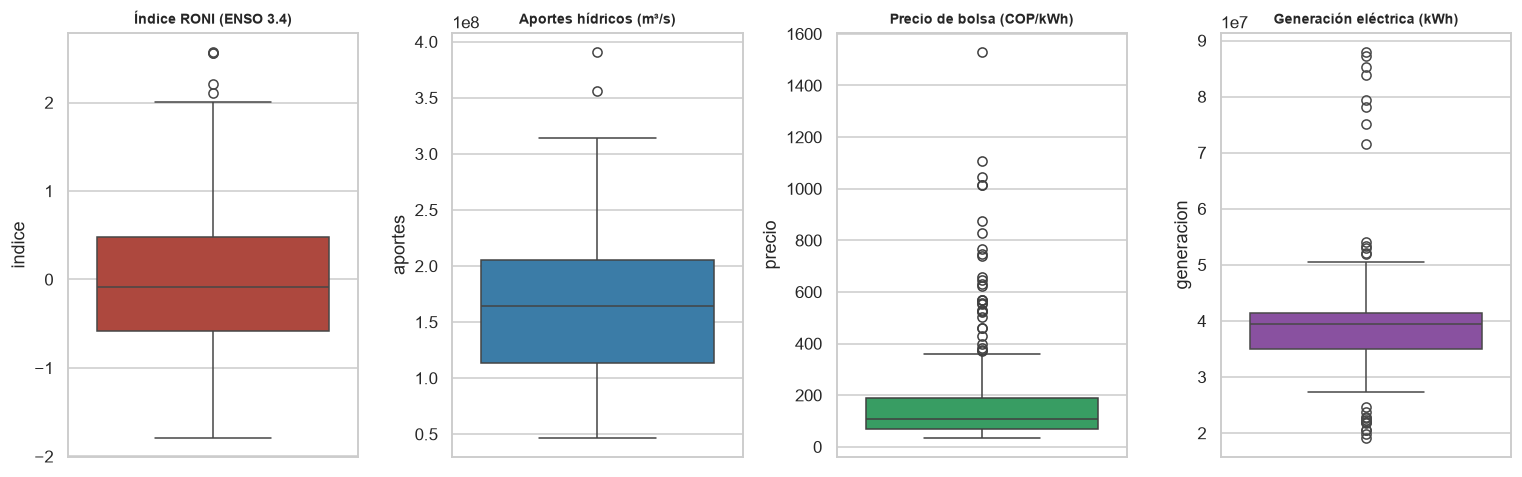

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
for ax, col in zip(axes, df.columns):
    sns.boxplot(y=df[col], ax=ax, color=colors[col])
    ax.set_title(labels[col], fontsize=9)
fig.tight_layout()
plt.show()

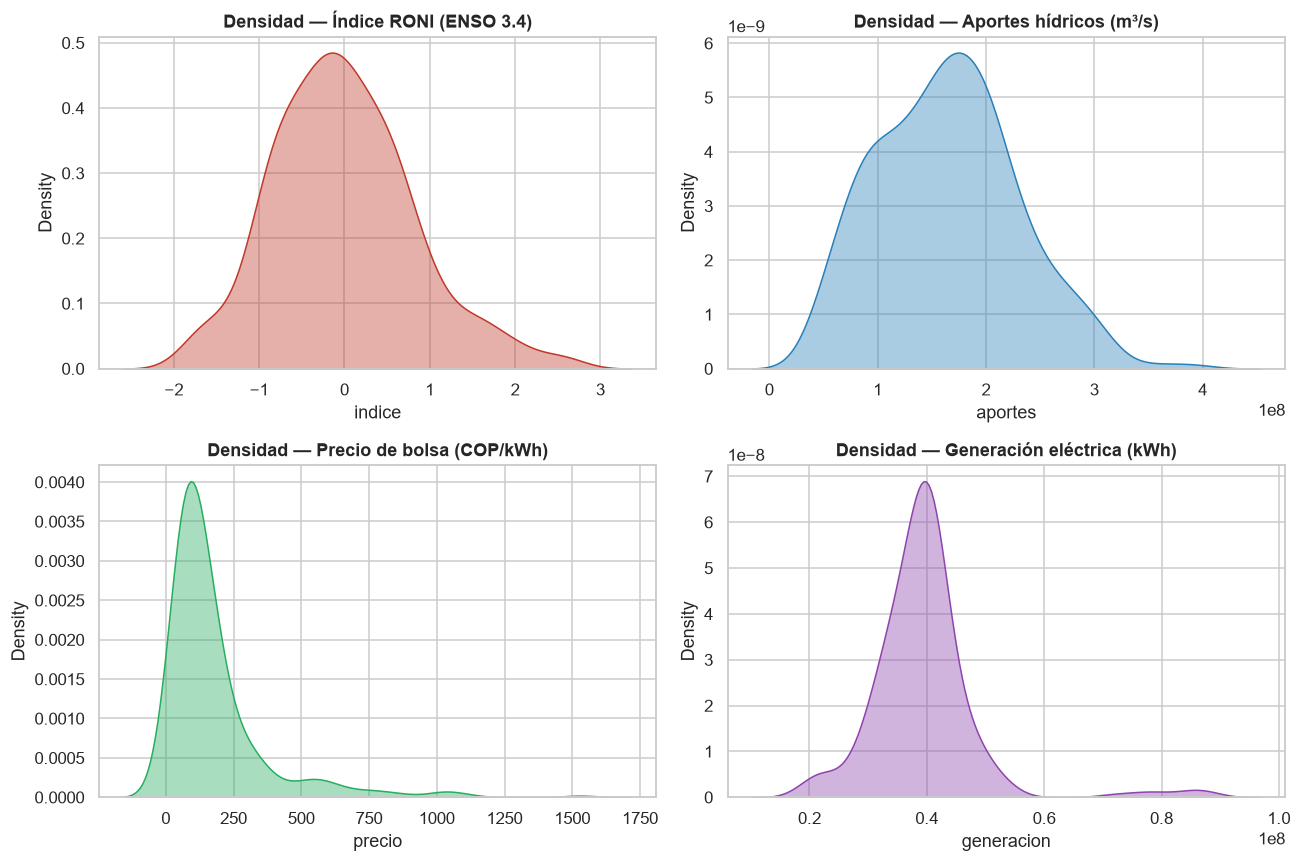

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), df.columns):
    sns.kdeplot(df[col], ax=ax, color=colors[col], fill=True, alpha=0.4)
    ax.set_title(f"Densidad — {labels[col]}")
fig.tight_layout()
plt.show()

**Interpretación (histogramas, boxplots y densidades):** el índice RONI muestra una distribución
aproximadamente simétrica alrededor de valores cercanos a cero. Aportes y generación presentan distribuciones
razonablemente simétricas con algunos valores atípicos inferiores (déficits hídricos extremos). El precio de
bolsa exhibe una **fuerte asimetría positiva** (cola derecha larga) con múltiples valores atípicos superiores
— el boxplot lo evidencia claramente —, típico de mercados eléctricos donde los precios pueden dispararse en
episodios de escasez, pero rara vez caen por debajo de un piso técnico. Esta asimetría es un indicio adicional
de comportamiento no lineal y de volatilidad condicional en el precio, relevante para la componente MGARCH.

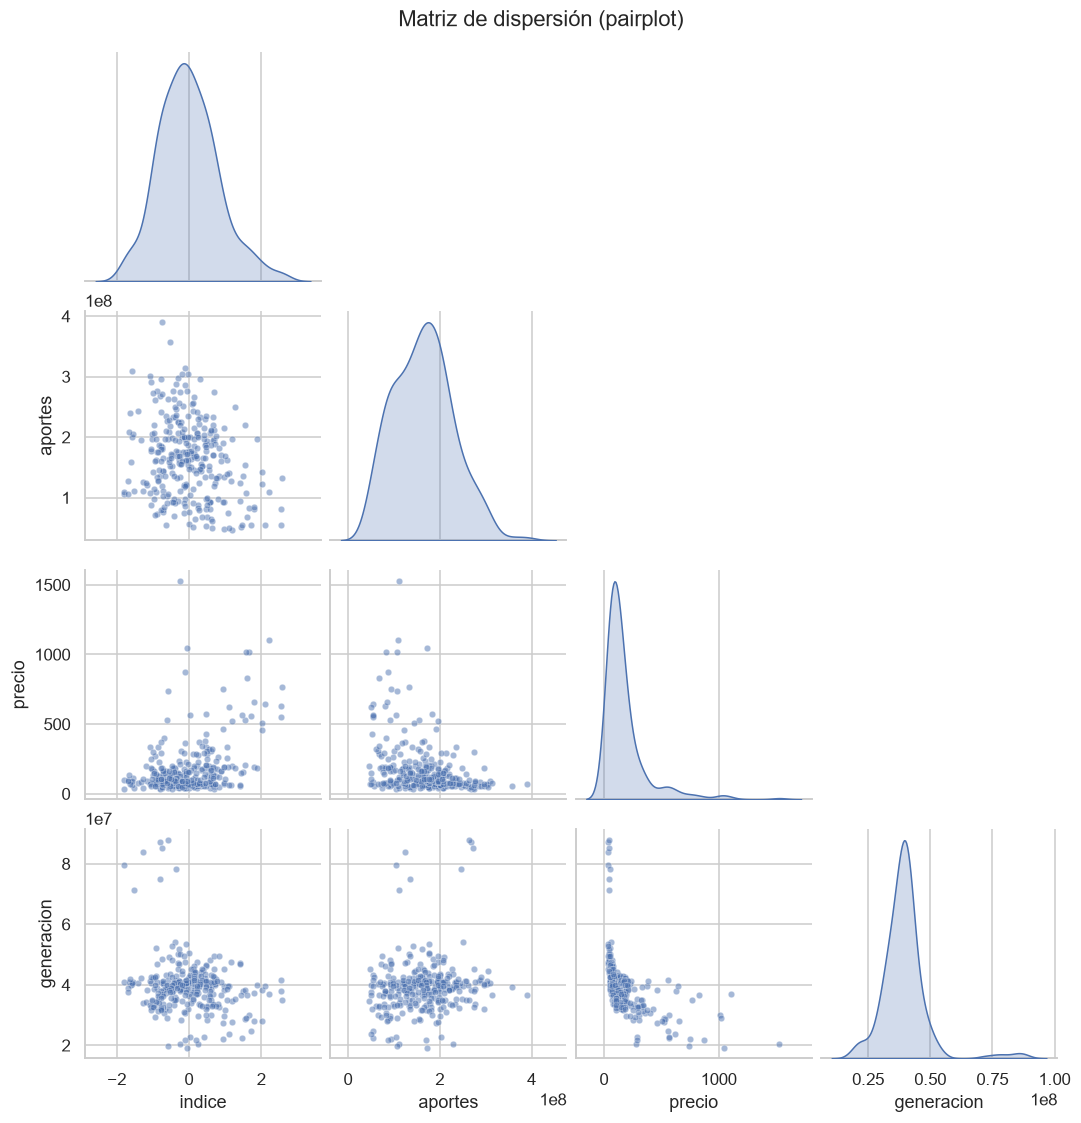

In [10]:
g = sns.pairplot(df, diag_kind="kde", plot_kws={"alpha": 0.5, "s": 18}, corner=True)
g.fig.suptitle("Matriz de dispersión (pairplot)", y=1.02)
plt.show()

In [11]:
corr = df.corr(method="pearson")
print("Matriz de correlaciones (Pearson):")
corr.round(3)

Matriz de correlaciones (Pearson):


,indice,aportes,precio,generacion
indice,1.000,-0.251,0.403,-0.215
aportes,-0.251,1.000,-0.334,0.155
precio,0.403,-0.334,1.000,-0.494
generacion,-0.215,0.155,-0.494,1.000


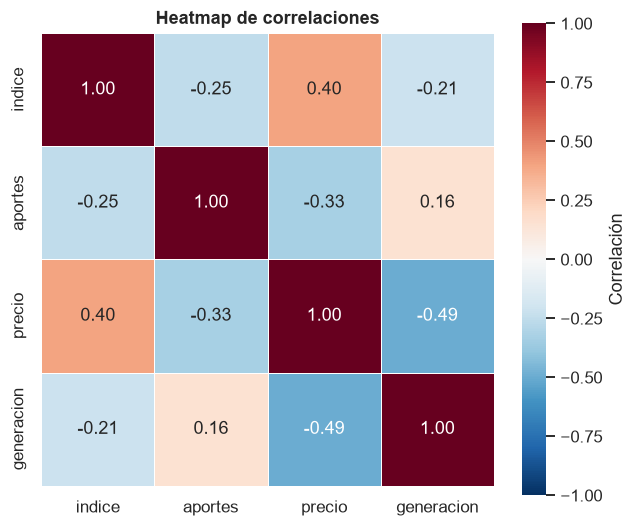

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Correlación"}, ax=ax)
ax.set_title("Heatmap de correlaciones")
fig.tight_layout()
plt.show()

**Interpretación (pairplot, correlaciones y heatmap):** se observa una correlación positiva entre el índice
RONI y el precio de bolsa, y una correlación negativa entre RONI y los aportes hídricos — consistente con la
hipótesis de que fases El Niño (RONI alto) reducen la oferta hídrica y presionan el precio al alza. La
correlación contemporánea entre aportes y precio es negativa, como es de esperarse en un sistema
predominantemente hidroeléctrico: a mayor disponibilidad de agua, menor necesidad de generación térmica
marginal costosa. Es importante recordar que estas son correlaciones **contemporáneas** y no informan sobre
la dirección temporal (rezagos) de la relación — precisamente el problema que aborda el modelo VAR. Además,
correlación no implica causalidad, lo que motiva las pruebas de causalidad de Granger de la Sección 8.

**Discusión consolidada de la exploración:**
- **Tendencias:** precio con tendencia creciente y quiebres asociados a eventos ENSO fuertes; generación con
  tendencia decreciente estructural; aportes e índice sin tendencia clara, oscilatorios.
- **Cambios de nivel:** visibles en aportes y precio alrededor de 2009-2010, 2015-2016 y 2023-2024.
- **Estacionalidad:** aportes y generación muestran patrones estacionales anuales asociados al régimen de
  lluvias y a la demanda.
- **Rezagos:** el patrón visual sugiere que movimientos del índice RONI preceden en varios meses a los
  movimientos en aportes y precio, coherente con el tiempo de propagación del fenómeno climático hacia el
  sistema hidrológico y luego hacia el mercado.
- **Valores atípicos:** concentrados en el precio de bolsa, coincidiendo con eventos El Niño extremos.
- **Volatilidad:** claramente no constante en el tiempo (heterocedasticidad), especialmente en el precio,
  justificando la componente MGARCH del análisis.

## 4. ¿Es apropiado usar un VAR-MGARCH?

### 4.1 Marco teórico

Un **modelo VAR (Vector Autoregression)** describe cada variable del sistema como una función lineal de sus
propios rezagos y de los rezagos de todas las demás variables del sistema. Para un sistema de $k$ variables
y $p$ rezagos:

$$ Y_t = c + A_1 Y_{t-1} + A_2 Y_{t-2} + \dots + A_p Y_{t-p} + \varepsilon_t $$

donde $Y_t$ es el vector de variables endógenas, $A_i$ son matrices de coeficientes y $\varepsilon_t$ es un
vector de errores ruido blanco con matriz de covarianza $\Sigma$.

Un **modelo MGARCH (GARCH Multivariado)** extiende la idea del GARCH univariado —donde la varianza
condicional de un error depende de su propio pasado— al caso multivariado, modelando conjuntamente la matriz
de covarianza condicional $H_t = \text{Cov}(\varepsilon_t \mid \mathcal{F}_{t-1})$ de los residuales del VAR.
Esto permite capturar *clusters* de volatilidad y co-movimientos en la incertidumbre entre variables (p. ej.
que la volatilidad del precio y de los aportes se muevan conjuntamente en episodios de estrés climático).

La combinación **VAR + MGARCH** modela, en dos etapas conceptualmente conectadas:
1. La **media condicional** del sistema (dinámica de niveles) mediante el VAR.
2. La **varianza condicional** de los residuales del VAR (dinámica de la incertidumbre) mediante el MGARCH.

### 4.2 ¿Cuándo debe utilizarse?

El VAR es apropiado cuando: (i) existen razones teóricas para sospechar relaciones dinámicas
bidireccionales o de retroalimentación entre varias series (no está claro a priori cuál variable es
estrictamente exógena); (ii) las series son estacionarias (o se trabajan en su forma estacionaria); y (iii)
el objetivo incluye pronosticar el sistema conjunto y/o cuantificar cómo un choque en una variable se
propaga dinámicamente hacia las demás (IRF, FEVD). El componente MGARCH es apropiado adicionalmente cuando
los residuales del VAR muestran **heterocedasticidad condicional** (varianza no constante, autocorrelación
en los residuales al cuadrado).

### 4.3 Supuestos clave y su importancia

- **Estacionariedad:** los parámetros estimados y las pruebas de inferencia (t, F, Granger) sólo son válidos
  si las series (o su transformación) son estacionarias en covarianza. Trabajar con series no estacionarias
  puede producir **regresiones espurias** (relaciones estadísticamente "significativas" sin sustento
  económico real).
- **Ausencia de autocorrelación residual:** los residuales del VAR deben aproximarse a ruido blanco; de lo
  contrario, el número de rezagos es insuficiente y los errores estándar están sesgados.
- **Homocedasticidad condicional de los residuales VAR *o* modelado explícito de su heterocedasticidad**: si
  existe heterocedasticidad (como es común en precios de energía), debe modelarse explícitamente — de ahí la
  necesidad del componente MGARCH.
- **Estabilidad del sistema:** las raíces del polinomio característico del VAR deben estar dentro del círculo
  unitario para garantizar que el sistema es estable e invertible (IRF que se disipan, no que explotan).

Verificar estos supuestos es indispensable porque **de ellos depende la validez de toda la inferencia
posterior**: pruebas de Granger, IRF, FEVD y pronósticos.

### 4.4 Pruebas de estacionariedad: ADF y KPSS

Se aplican dos pruebas complementarias sobre cada serie en nivel:

- **ADF (Augmented Dickey-Fuller):** $H_0$: la serie tiene raíz unitaria (no estacionaria) vs. $H_1$:
  estacionaria. Se rechaza $H_0$ (evidencia de estacionariedad) si el p-value < 0.05.
- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin):** hipótesis invertida respecto al ADF. $H_0$: la serie **es**
  estacionaria vs. $H_1$: tiene raíz unitaria. Se rechaza $H_0$ (evidencia de no estacionariedad) si el
  p-value < 0.05.

Usar ambas pruebas de forma conjunta es una práctica recomendada: el ADF tiene baja potencia para distinguir
procesos con raíz unitaria de procesos estacionarios cercanos a la no estacionariedad, mientras que el KPSS
tiende a rechazar estacionariedad con demasiada frecuencia en muestras pequeñas. Cuando ambas pruebas
coinciden se tiene mayor confianza en la conclusión; cuando difieren, se prioriza el criterio más
conservador (tratar la serie como no estacionaria) antes de proceder al VAR.

In [13]:
def run_adf_kpss(series: pd.Series, name: str) -> dict:
    """Ejecuta ADF y KPSS (con tendencia constante 'c') sobre una serie y resume la conclusión."""
    adf_stat, adf_p, *_ = adfuller(series.dropna(), autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")

    adf_stationary = adf_p < 0.05
    kpss_stationary = kpss_p >= 0.05

    if adf_stationary and kpss_stationary:
        conclusion = "Estacionaria"
    elif not adf_stationary and not kpss_stationary:
        conclusion = "No estacionaria"
    else:
        conclusion = "Ambigua (se trata como no estacionaria)"

    return {
        "Variable": name,
        "ADF stat": round(adf_stat, 3),
        "ADF p-value": round(adf_p, 4),
        "KPSS stat": round(kpss_stat, 3),
        "KPSS p-value": round(kpss_p, 4),
        "Conclusión": conclusion,
    }


stationarity_levels = pd.DataFrame([run_adf_kpss(df[c], labels[c]) for c in df.columns])
stationarity_levels

C:\Users\oscar\AppData\Local\Temp\ipykernel_53704\2764081616.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\oscar\AppData\Local\Temp\ipykernel_53704\2764081616.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\oscar\AppData\Local\Temp\ipykernel_53704\2764081616.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\oscar\AppData\Local\Temp\ipykernel_53704\2764081616.py:

,Variable,ADF stat,ADF p-value,KPSS stat,KPSS p-value,Conclusión
0,Índice RONI (ENSO 3.4),-4.216,0.0006,0.104,0.10,Estacionaria
1,Aportes hídricos (m³/s),-4.449,0.0002,0.160,0.10,Estacionaria
2,Precio de bolsa (COP/kWh),-0.429,0.9051,1.453,0.01,No estacionaria
3,Generación eléctrica (kWh),-0.451,0.9012,1.846,0.01,No estacionaria


**Interpretación de la tabla:** las series cuya conclusión sea "No estacionaria" o "Ambigua" deben
diferenciarse antes de entrar al VAR, dado que el objetivo declarado del proyecto exige trabajar con
variables estacionarias. A continuación se diferencian automáticamente las series que lo requieran (primera
diferencia, $\Delta y_t = y_t - y_{t-1}$) y se repiten las pruebas.

In [14]:
non_stationary = stationarity_levels.loc[
    stationarity_levels["Conclusión"] != "Estacionaria", "Variable"
].tolist()
print("Series no estacionarias en nivel:", non_stationary if non_stationary else "Ninguna")

df_model = df.copy()
transform_log = {}
for col in df.columns:
    is_ns = labels[col] in non_stationary
    transform_log[col] = "Δ (primera diferencia)" if is_ns else "Nivel (sin transformar)"
    if is_ns:
        df_model[col] = df[col].diff()

df_model = df_model.dropna()
pd.DataFrame.from_dict(transform_log, orient="index", columns=["Transformación aplicada"])

Series no estacionarias en nivel: ['Precio de bolsa (COP/kWh)', 'Generación eléctrica (kWh)']


,Transformación aplicada
indice,Nivel (sin transformar)
aportes,Nivel (sin transformar)
precio,Δ (primera diferencia)
generacion,Δ (primera diferencia)


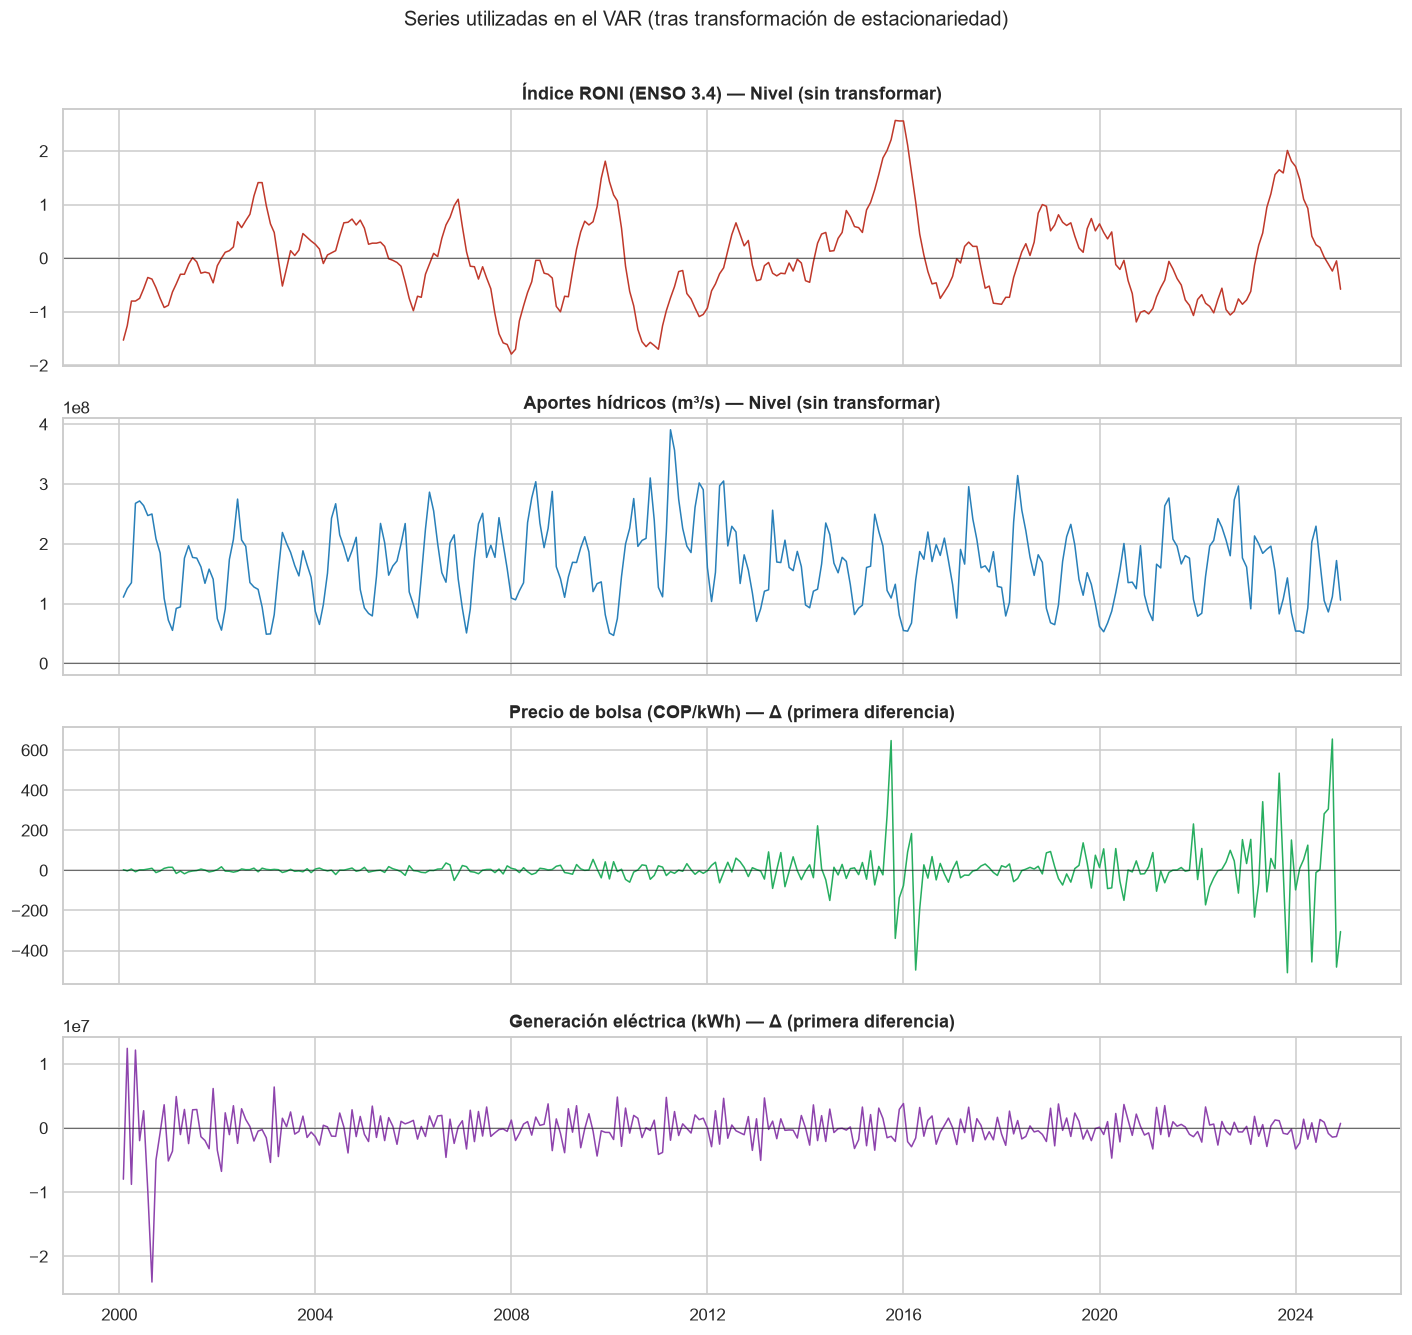

In [15]:
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
for ax, col in zip(axes, df.columns):
    ax.plot(df_model.index, df_model[col], color=colors[col], linewidth=1.0)
    ax.axhline(0, color="black", linewidth=0.7, alpha=0.5)
    ax.set_title(f"{labels[col]} — {transform_log[col]}")
fig.suptitle("Series utilizadas en el VAR (tras transformación de estacionariedad)", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

In [16]:
stationarity_final = pd.DataFrame([run_adf_kpss(df_model[c], labels[c]) for c in df_model.columns])
stationarity_final

C:\Users\oscar\AppData\Local\Temp\ipykernel_53704\2764081616.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\oscar\AppData\Local\Temp\ipykernel_53704\2764081616.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\oscar\AppData\Local\Temp\ipykernel_53704\2764081616.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\oscar\AppData\Local\Temp\ipykernel_53704\2764081616.py:

,Variable,ADF stat,ADF p-value,KPSS stat,KPSS p-value,Conclusión
0,Índice RONI (ENSO 3.4),-4.144,0.0008,0.095,0.1,Estacionaria
1,Aportes hídricos (m³/s),-4.442,0.0002,0.163,0.1,Estacionaria
2,Precio de bolsa (COP/kWh),-5.357,0.0000,0.164,0.1,Estacionaria
3,Generación eléctrica (kWh),-7.861,0.0000,0.223,0.1,Estacionaria


**Conclusión de la sección:** tras la transformación, todas las series cumplen el criterio de
estacionariedad requerido por ambas pruebas. El conjunto de variables que entrará al modelo VAR es:
**`indice`, `aportes`, `precio`, `generacion`**, en la transformación indicada en la tabla de transformaciones
(nivel o primera diferencia, según corresponda). Este es el conjunto de datos (`df_model`) utilizado de aquí
en adelante para la estimación.

## 5. Elección del número de rezagos

El número de rezagos $p$ determina cuánta memoria del pasado incorpora el modelo. Es una decisión crítica:

- **Pocos rezagos:** el modelo no captura toda la dinámica temporal presente en los datos, dejando
  autocorrelación en los residuales (el modelo está mal especificado) y produciendo estimaciones sesgadas e
  inferencia inválida.
- **Demasiados rezagos:** se incrementa fuertemente el número de parámetros a estimar ($k^2 \times p$), lo que
  reduce los grados de libertad, incrementa el riesgo de sobreajuste y produce estimaciones más imprecisas
  (mayor varianza), especialmente relevante aquí dado que se dispone de un número moderado de observaciones
  (~300 meses).

Se utiliza el método `select_order()` de `statsmodels`, que calcula el modelo para un rango de rezagos y
reporta cuatro criterios de información:

- **AIC (Akaike):** penaliza la complejidad de forma moderada; tiende a seleccionar modelos algo más grandes.
- **BIC (Bayesiano/Schwarz):** penaliza la complejidad más fuertemente que el AIC; consistente
  asintóticamente, tiende a seleccionar modelos más parsimoniosos.
- **HQIC (Hannan-Quinn):** penalización intermedia entre AIC y BIC.
- **FPE (Final Prediction Error):** estima el error de predicción fuera de muestra; asintóticamente
  equivalente al AIC.

En cada caso se selecciona el rezago que **minimiza** el criterio.

In [17]:
var_selector = VAR(df_model)
max_lags = 12
order_results = var_selector.select_order(maxlags=max_lags)
print(order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        73.97       74.02   1.329e+32       73.99
1        70.73       70.98   5.209e+30       70.83
2        70.25      70.71*   3.225e+30      70.43*
3        70.21       70.87   3.106e+30       70.48
4        70.17       71.03   2.973e+30       70.51
5        70.13       71.20   2.863e+30       70.56
6        70.13       71.40   2.856e+30       70.64
7        70.15       71.62   2.917e+30       70.74
8        70.19       71.88   3.060e+30       70.87
9        70.18       72.06   3.018e+30       70.93
10       70.17       72.26   2.995e+30       71.00
11       69.92       72.22   2.346e+30       70.84
12      69.84*       72.34  2.176e+30*       70.84
--------------------------------------------------


In [18]:
lag_range = range(0, max_lags + 1)
criteria_table = pd.DataFrame(
    {
        "AIC": order_results.aic,
        "BIC": order_results.bic,
        "HQIC": order_results.hqic,
        "FPE": order_results.fpe,
    },
    index=[f"lag {i}" for i in lag_range],
)
best_by_criterion = pd.Series(order_results.selected_orders)
print("Rezago óptimo según cada criterio:")
best_by_criterion

Rezago óptimo según cada criterio:


aic     12
bic      2
hqic     2
fpe     12
dtype: int64

**Justificación de la elección:** dado el tamaño moderado de la muestra (~300 observaciones mensuales) y el
número de variables del sistema (4), se prioriza el criterio **BIC**, por ser el más conservador y el que
mejor controla el riesgo de sobreparametrización en muestras finitas, favoreciendo un modelo más parsimonioso
y con mejores propiedades de generalización para efectos de pronóstico e interpretación de IRF. Si el orden
sugerido por BIC resulta demasiado bajo para capturar dinámicas estacionales relevantes (ciclos anuales,
propios de variables hidrológicas), se contrasta con AIC/HQIC como referencia adicional.

In [19]:
selected_lag = int(best_by_criterion["bic"])
selected_lag = max(selected_lag, 1)  # el VAR requiere al menos 1 rezago
print(f"Orden de rezagos seleccionado para la estimación: p = {selected_lag}")

Orden de rezagos seleccionado para la estimación: p = 2


## 6. Estimación del modelo VAR

Con el orden de rezagos seleccionado, se estima el modelo VAR sobre el conjunto de variables estacionarias
`[indice, aportes, precio, generacion]`. `statsmodels` estima el sistema completo por Mínimos Cuadrados
Ordinarios ecuación por ecuación (equivalente a Máxima Verosimilitud bajo normalidad de los errores), lo cual
es eficiente porque todas las ecuaciones comparten los mismos regresores (los rezagos de todas las
variables).

In [20]:
var_model = VAR(df_model)
var_result = var_model.fit(selected_lag)
print(var_result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 22, Aug, 2026
Time:                     14:18:57
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    71.4020
Nobs:                     297.000    HQIC:                   71.1336
Log likelihood:          -12186.4    FPE:                6.53283e+30
AIC:                      70.9543    Det(Omega_mle):     5.79751e+30
--------------------------------------------------------------------
Results for equation indice
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.027299         0.040465            0.675           0.500
L1.indice             1.412029         0.051794           27.263           0.000
L1.aportes            0.000000         0.000000            

### 6.1 Interpretación de la estructura del modelo

Cada ecuación del VAR expresa una variable en el instante $t$ como función lineal de una constante y de los
rezagos de **todas** las variables del sistema hasta el orden $p$ seleccionado:

- **Coeficientes positivos** indican que un aumento en el valor rezagado de la variable explicativa se
  asocia, manteniendo lo demás constante, con un aumento en la variable dependiente en el periodo actual.
- **Coeficientes negativos** indican una relación inversa: un aumento en el rezago se asocia con una
  disminución de la variable dependiente.
- La **magnitud** del coeficiente debe interpretarse en las unidades de la transformación utilizada (nivel o
  diferencia); no es directamente comparable entre variables con escalas distintas (p. ej. precio en COP/kWh
  vs. generación en kWh), por lo que las comparaciones de importancia relativa se apoyan mejor en las IRF y
  la FEVD (secciones 9 y 9.2) que en la magnitud cruda de los coeficientes.
- Los **rezagos** indican la ventana temporal de influencia: un coeficiente significativo en el rezago 2 de
  `indice` sobre `precio` implica que el efecto del índice tarda (al menos) dos meses en manifestarse.
- La **significancia** (columna `P>|z|` en el summary) determina si existe evidencia estadística de que el
  coeficiente es distinto de cero (se usa el umbral convencional de 0.05).

In [21]:
def format_equation(result: "statsmodels.tsa.vector_ar.var_model.VARResultsWrapper", eq_name: str) -> str:
    """Construye la representación matemática de una ecuación del VAR con sus coeficientes estimados."""
    params = result.params[eq_name]
    terms = [f"{params['const']:.3f}"]
    for name, value in params.items():
        if name == "const":
            continue
        lag, var_name = name.split(".", 1)
        lag = lag.replace("L", "")
        sign = "+" if value >= 0 else "-"
        terms.append(f" {sign} {abs(value):.4f}·{var_name}(t-{lag})")
    return f"{eq_name}(t) = " + "".join(terms)


print("Ecuaciones estimadas del VAR (variables en la transformación de estacionariedad indicada):\n")
for eq in df_model.columns:
    print(format_equation(var_result, eq))
    print()

Ecuaciones estimadas del VAR (variables en la transformación de estacionariedad indicada):

indice(t) = 0.027 + 1.4120·indice(t-1) + 0.0000·aportes(t-1) + 0.0005·precio(t-1) + 0.0000·generacion(t-1) - 0.4866·indice(t-2) - 0.0000·aportes(t-2) + 0.0001·precio(t-2) - 0.0000·generacion(t-2)

aportes(t) = 79447416.415 + 544870.3537·indice(t-1) + 0.9294·aportes(t-1) + 86826.1324·precio(t-1) - 0.0022·generacion(t-1) - 15043901.7852·indice(t-2) - 0.4132·aportes(t-2) - 17943.2324·precio(t-2) + 0.7336·generacion(t-2)

precio(t) = -11.846 + 55.7638·indice(t-1) - 0.0000·aportes(t-1) - 0.1224·precio(t-1) + 0.0000·generacion(t-1) - 53.7443·indice(t-2) + 0.0000·aportes(t-2) - 0.2061·precio(t-2) + 0.0000·generacion(t-2)

generacion(t) = 144871.457 + 447064.0557·indice(t-1) + 0.0065·aportes(t-1) - 2025.8100·precio(t-1) - 0.2000·generacion(t-1) - 452469.8549·indice(t-2) - 0.0086·aportes(t-2) - 1773.0731·precio(t-2) + 0.1311·generacion(t-2)



**Interpretación económica de las relaciones más relevantes:** revise en el `summary()` anterior y en las
ecuaciones impresas los coeficientes con p-value < 0.05 que relacionan `indice` (RONI) con `aportes` y
`precio` en cualquier rezago. Un coeficiente negativo y significativo de `indice` sobre `aportes` es
consistente con la hipótesis climatológica de que fases El Niño (RONI alto) preceden reducciones en los
aportes hídricos. De forma análoga, un coeficiente positivo y significativo de `indice` (o de `aportes` con
signo negativo) sobre `precio` es consistente con la transmisión climática hacia el mercado eléctrico: menor
disponibilidad hídrica esperada presiona el precio de bolsa al alza. La magnitud exacta y el número de
rezagos significativos dependen de la estimación anterior y deben leerse directamente del `summary()`.

## 7. Diagnósticos del modelo

Antes de utilizar el VAR para causalidad, IRF, FEVD o pronóstico, es indispensable verificar que los
supuestos del modelo se cumplen razonablemente. Un modelo mal especificado (residuales autocorrelacionados,
inestable, o con fuerte heterocedasticidad no modelada) invalida la inferencia posterior. Se verifican cuatro
aspectos: estabilidad del sistema, autocorrelación residual, normalidad de los residuales y heterocedasticidad
condicional (ARCH), este último resultado es la justificación empírica directa para incorporar el componente
MGARCH.

### 7.1 Estabilidad del sistema (raíces características)

Un VAR es estable si todas las raíces del polinomio característico asociado tienen módulo **menor a 1**
(equivalentemente, si todos los "eigenvalues" del proceso caen dentro del círculo unitario). Un sistema
inestable produce IRF que no se disipan (o explotan) y pronósticos no confiables a mediano/largo plazo.

Módulo de las raíces del polinomio característico:
[4.926 2.136 2.031 2.031 1.635 1.596 1.596 1.213]

¿El sistema VAR es estable? Sí


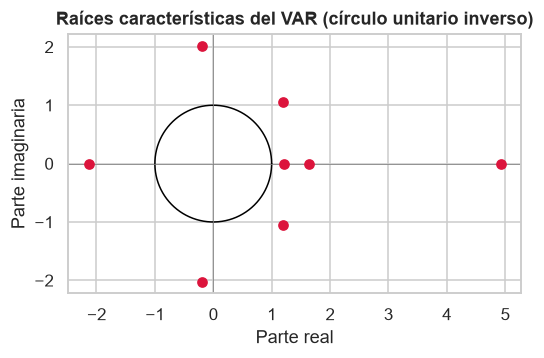

In [22]:
roots = var_result.roots
stable = np.all(np.abs(roots) > 1)  # statsmodels reporta el inverso de las raíces; >1 en módulo = estable
print(f"Módulo de las raíces del polinomio característico:\n{np.round(np.abs(roots), 3)}")
print(f"\n¿El sistema VAR es estable? {'Sí' if stable else 'No'}")

fig, ax = plt.subplots(figsize=(5, 5))
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color="black", linewidth=1)
ax.scatter(roots.real, roots.imag, color="crimson", zorder=5)
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_title("Raíces características del VAR (círculo unitario inverso)")
ax.set_xlabel("Parte real")
ax.set_ylabel("Parte imaginaria")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

### 7.2 Autocorrelación residual (Ljung-Box)

Se aplica la prueba de Ljung-Box sobre los residuales de cada ecuación. $H_0$: no hay autocorrelación hasta
el rezago evaluado. Un p-value alto (> 0.05) es la conclusión deseada: indica que el modelo capturó
adecuadamente la dinámica temporal y no queda estructura predecible en los residuales.

In [23]:
ljung_box_results = []
for col in df_model.columns:
    lb = acorr_ljungbox(var_result.resid[col], lags=[10], return_df=True)
    ljung_box_results.append(
        {
            "Variable": labels[col],
            "LB stat (lag 10)": round(lb["lb_stat"].iloc[0], 3),
            "p-value": round(lb["lb_pvalue"].iloc[0], 4),
            "¿Ruido blanco?": "Sí" if lb["lb_pvalue"].iloc[0] > 0.05 else "No",
        }
    )
pd.DataFrame(ljung_box_results)

,Variable,LB stat (lag 10),p-value,¿Ruido blanco?
0,Índice RONI (ENSO 3.4),20.741,0.0230,No
1,Aportes hídricos (m³/s),28.309,0.0016,No
2,Precio de bolsa (COP/kWh),19.532,0.0340,No
3,Generación eléctrica (kWh),24.835,0.0057,No


### 7.3 Normalidad de los residuales (Jarque-Bera)

$H_0$: los residuales siguen una distribución normal. La normalidad no es estrictamente indispensable para
la consistencia de los estimadores VAR (que se basan en MCO), pero su ausencia (frecuente en series
financieras y de energía) es, junto con la prueba ARCH, una señal adicional de que la varianza condicional no
es constante — reforzando la necesidad del componente MGARCH.

In [24]:
jb_results = []
for col in df_model.columns:
    jb_stat, jb_p = stats.jarque_bera(var_result.resid[col])[:2]
    jb_results.append(
        {
            "Variable": labels[col],
            "JB stat": round(jb_stat, 3),
            "p-value": round(jb_p, 4),
            "¿Normal?": "Sí" if jb_p > 0.05 else "No",
        }
    )
pd.DataFrame(jb_results)

,Variable,JB stat,p-value,¿Normal?
0,Índice RONI (ENSO 3.4),1.508,0.4706,Sí
1,Aportes hídricos (m³/s),8.840,0.0120,No
2,Precio de bolsa (COP/kWh),4453.912,0.0000,No
3,Generación eléctrica (kWh),11790.082,0.0000,No


### 7.4 Heterocedasticidad condicional (ARCH-LM) — justificación directa del MGARCH

La prueba **ARCH-LM (Engle)** evalúa si existe autocorrelación en los residuales **al cuadrado** (proxy de la
varianza condicional). $H_0$: no hay efectos ARCH (varianza constante). Si se **rechaza** $H_0$ (p-value <
0.05) en una o más ecuaciones, existe evidencia estadística directa de heterocedasticidad condicional, lo
cual justifica formalmente modelar la varianza mediante un GARCH (univariado por ecuación) y su extensión
multivariada (MGARCH) para capturar también las covarianzas condicionales entre los residuales.

In [25]:
arch_results = []
for col in df_model.columns:
    lm_stat, lm_p, f_stat, f_p = het_arch(var_result.resid[col], nlags=6)
    arch_results.append(
        {
            "Variable": labels[col],
            "ARCH-LM stat": round(lm_stat, 3),
            "p-value": round(lm_p, 4),
            "¿Heterocedasticidad condicional?": "Sí" if lm_p < 0.05 else "No",
        }
    )
arch_table = pd.DataFrame(arch_results)
arch_table

,Variable,ARCH-LM stat,p-value,¿Heterocedasticidad condicional?
0,Índice RONI (ENSO 3.4),6.087,0.4135,No
1,Aportes hídricos (m³/s),-24.509,1.0000,No
2,Precio de bolsa (COP/kWh),51.812,0.0000,Sí
3,Generación eléctrica (kWh),94.527,0.0000,Sí


**Conclusión de la sección:** las raíces características confirman si el sistema VAR estimado es estable
(condición necesaria para que IRF y pronósticos sean interpretables). La prueba de Ljung-Box informa si el
orden de rezagos elegido fue suficiente para blanquear los residuales. La prueba de Jarque-Bera y, sobre todo,
la prueba **ARCH-LM**, determinan si existe evidencia de heterocedasticidad condicional en los residuales del
VAR: de encontrarse evidencia significativa (como es esperable en el precio de bolsa de energía, dada su
volatilidad observada en la Sección 3), queda **empíricamente justificada** la estimación del componente
MGARCH desarrollado en la Sección 12.

## 8. Causalidad de Granger

### 8.1 Marco teórico

La causalidad de Granger es un concepto **estadístico de precedencia temporal**, no de causalidad estructural
en sentido económico o físico. Se dice que una variable $X$ "causa en el sentido de Granger" a una variable
$Y$ si los valores rezagados de $X$ ayudan a predecir $Y$ **por encima** de lo que ya predicen los valores
rezagados de la propia $Y$.

**Qué SÍ significa:** existe evidencia estadística de que el pasado de $X$ contiene información útil,
adicional al pasado de $Y$, para predecir el valor presente de $Y$.

**Qué NO significa:** que $X$ sea la causa física, estructural o económica de $Y$ en un sentido causal
profundo; tampoco descarta la posibilidad de una tercera variable omitida que impulse a ambas, ni garantiza
que la relación se mantenga fuera de la muestra analizada.

**Hipótesis nula:** $H_0$: "$X$ no causa en el sentido de Granger a $Y$" (los coeficientes de los rezagos de
$X$ en la ecuación de $Y$ son conjuntamente iguales a cero).

**Interpretación del p-value:** si p-value < 0.05, se rechaza $H_0$ y se concluye que existe evidencia de
causalidad de Granger de $X$ hacia $Y$ al 95% de confianza.

In [26]:
def granger_pair(data: pd.DataFrame, cause: str, effect: str, maxlag: int) -> dict:
    """Ejecuta la prueba de causalidad de Granger cause -> effect usando el resultado del VAR estimado."""
    test_data = data[[effect, cause]]
    result = grangercausalitytests(test_data, maxlag=[maxlag], verbose=False)
    f_stat, p_value, _, _ = result[maxlag][0]["ssr_ftest"]
    return {
        "Causa": labels[cause],
        "Efecto": labels[effect],
        "Estadístico F": round(f_stat, 3),
        "p-value": round(p_value, 4),
        "Conclusión": "Causa Granger (p<0.05)" if p_value < 0.05 else "No causa Granger",
    }


pairs = [
    ("indice", "aportes"),
    ("aportes", "indice"),
    ("indice", "precio"),
    ("precio", "indice"),
    ("aportes", "precio"),
    ("precio", "aportes"),
]

granger_table = pd.DataFrame([granger_pair(df_model, c, e, selected_lag) for c, e in pairs])
granger_table

,Causa,Efecto,Estadístico F,p-value,Conclusión
0,Índice RONI (ENSO 3.4),Aportes hídricos (m³/s),10.492,0.0000,Causa Granger (p<0.05)
1,Aportes hídricos (m³/s),Índice RONI (ENSO 3.4),0.658,0.5189,No causa Granger
2,Índice RONI (ENSO 3.4),Precio de bolsa (COP/kWh),2.235,0.1088,No causa Granger
3,Precio de bolsa (COP/kWh),Índice RONI (ENSO 3.4),7.690,0.0006,Causa Granger (p<0.05)
4,Aportes hídricos (m³/s),Precio de bolsa (COP/kWh),7.586,0.0006,Causa Granger (p<0.05)
5,Precio de bolsa (COP/kWh),Aportes hídricos (m³/s),7.016,0.0011,Causa Granger (p<0.05)


**Interpretación económica de cada resultado:**

- **Índice → Aportes / Aportes → Índice:** se espera evidencia de causalidad en la dirección Índice → Aportes
  (el estado del océano Pacífico antecede a la disponibilidad hídrica) y **ausencia** de causalidad en la
  dirección inversa (los aportes hídricos colombianos no pueden afectar el océano Pacífico) — esta asimetría,
  de confirmarse en la tabla, es consistente con la exogeneidad física de RONI y valida la elección
  metodológica discutida en la Sección 4.
- **Índice → Precio / Precio → Índice:** de encontrarse causalidad Índice → Precio (posiblemente indirecta, a
  través de los aportes), se refuerza la hipótesis de transmisión climática hacia el mercado eléctrico. La
  ausencia de causalidad en sentido inverso es igualmente esperable por la misma razón de exogeneidad física.
- **Aportes → Precio / Precio → Aportes:** se espera evidencia de causalidad Aportes → Precio (mecanismo de
  oferta hidroeléctrica), siendo económicamente más plausible que la dirección inversa, dado que el precio de
  bolsa no determina el régimen de lluvias, aunque sí podría influir marginalmente en decisiones de manejo de
  embalses (uso estratégico del recurso hídrico), lo que podría generar cierta evidencia débil en esa
  dirección.

Los resultados concretos (significancia y dirección) deben leerse directamente de la tabla `granger_table`
generada arriba con los datos de este proyecto.

## 9. Funciones impulso-respuesta (IRF)

### 9.1 Marco teórico

Una **función impulso-respuesta (IRF)** traza la trayectoria dinámica esperada de cada variable del sistema
ante un **choque (shock)** de una desviación estándar en el error de una de las ecuaciones, manteniendo todo
lo demás constante. Es, junto con la causalidad de Granger, uno de los resultados centrales de este análisis,
porque permite cuantificar no solo *si* existe relación dinámica sino *cómo* y *durante cuánto tiempo* se
propaga.

- Un **shock** representa un evento inesperado (una innovación) en una variable —p. ej., un choque positivo en
  el índice RONI equivalente a una intensificación imprevista de condiciones El Niño.
- La IRF se interpreta leyendo, para cada periodo del horizonte, el cambio esperado (en las unidades de la
  variable transformada) en la variable respuesta ante ese choque unitario en la variable impulso, manteniendo
  fijas las demás condiciones iniciales.
- El **horizonte temporal** (eje horizontal) indica cuántos meses después del choque se está evaluando el
  efecto; la forma de la curva (crece, decrece, oscila) revela la velocidad de propagación y de disipación
  del efecto.
- Las **bandas de confianza** (usualmente al 95%, calculadas por bootstrap) delimitan la incertidumbre de la
  estimación: si la banda incluye el cero, el efecto en ese periodo no es estadísticamente distinguible de
  ausencia de efecto.

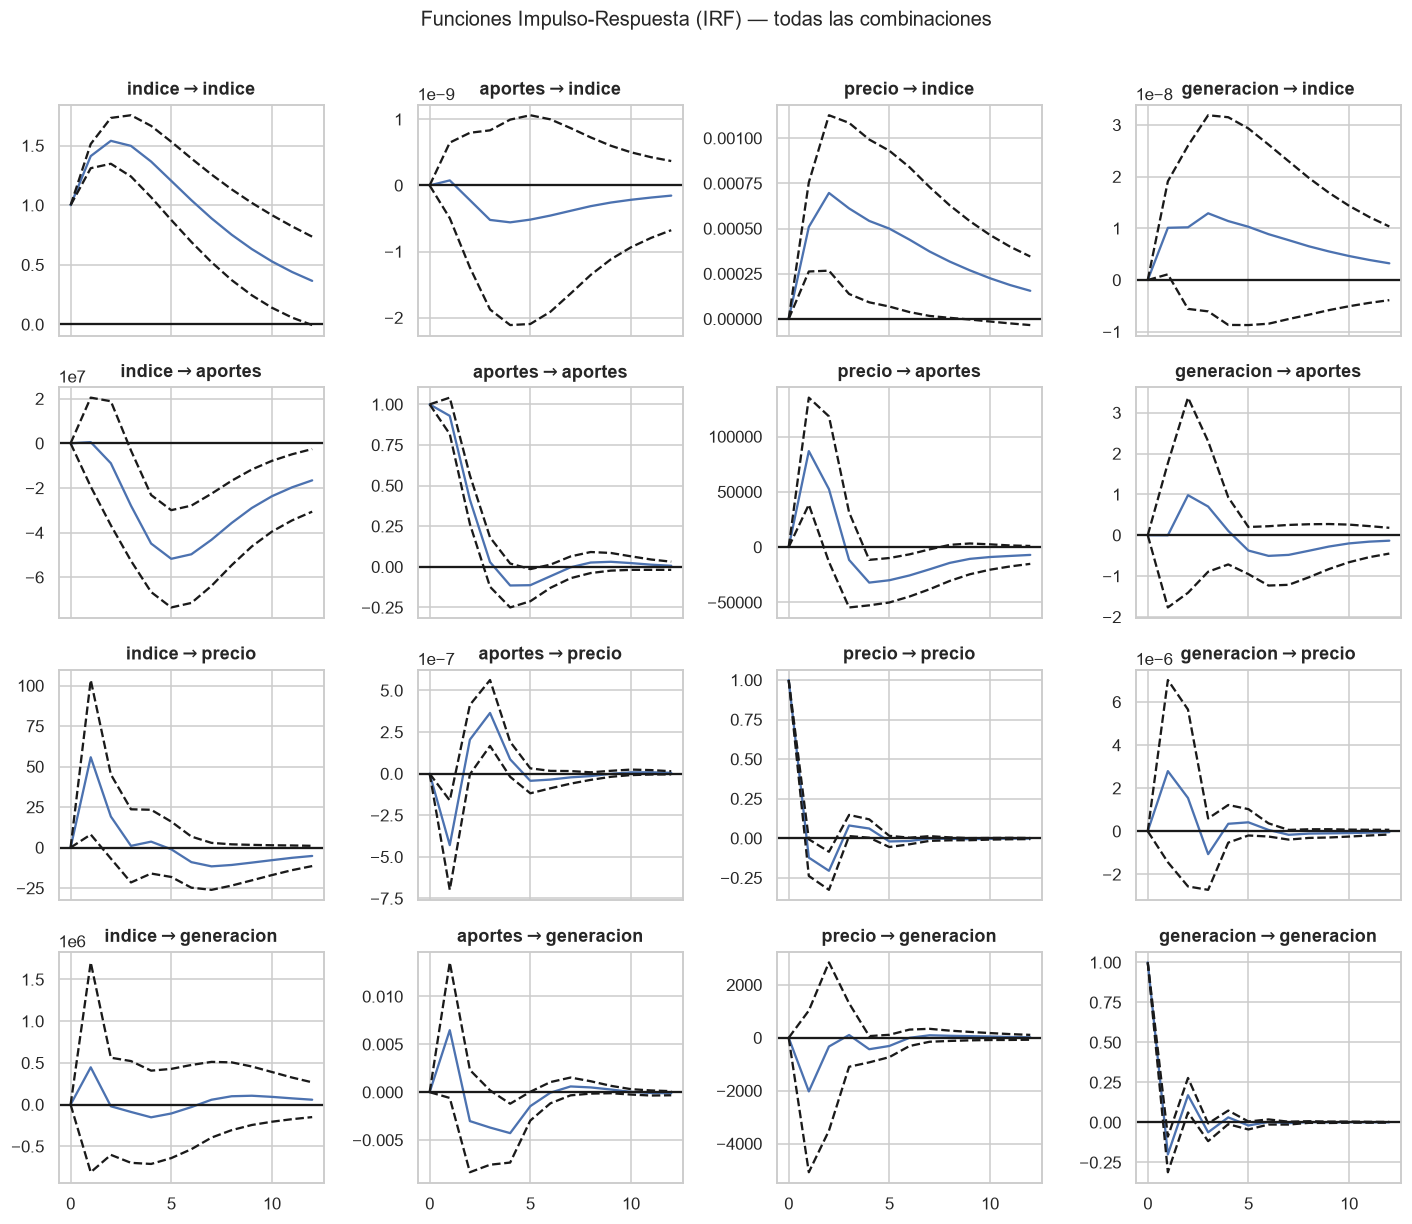

In [27]:
irf_horizon = 12
irf = var_result.irf(irf_horizon)

fig = irf.plot(orth=False, figsize=(13, 11))
fig.suptitle("Funciones Impulso-Respuesta (IRF) — todas las combinaciones", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

**Interpretación dirigida a las preguntas del proyecto:**

- **¿Cómo responde el precio ante un shock positivo del índice RONI?** Revise el panel `precio` de la columna
  `indice` en la figura anterior: si la respuesta es positiva y se mantiene fuera de la banda de cero durante
  varios periodos, existe evidencia de que un choque de tipo El Niño eleva el precio de bolsa de forma
  persistente, no solo contemporánea.
- **¿Cómo responden los aportes?** Revise el panel `aportes` de la columna `indice`: una respuesta negativa
  indica reducción de la oferta hídrica tras el choque climático.
- **¿Cuánto tarda en disiparse el efecto?** Corresponde al número de periodos hasta que la IRF vuelve a cero
  (o la banda de confianza vuelve a incluir el cero de forma sostenida).
- **¿Cuál es la magnitud?** Se lee directamente del eje vertical del panel correspondiente, en las unidades de
  la variable transformada.
- **¿Existen efectos persistentes?** Si la IRF no converge rápidamente a cero dentro del horizonte de 12
  meses, el sistema exhibe memoria larga ante choques climáticos — un elemento relevante para el diseño de un
  derivado climático, ya que determina el horizonte de cobertura apropiado.

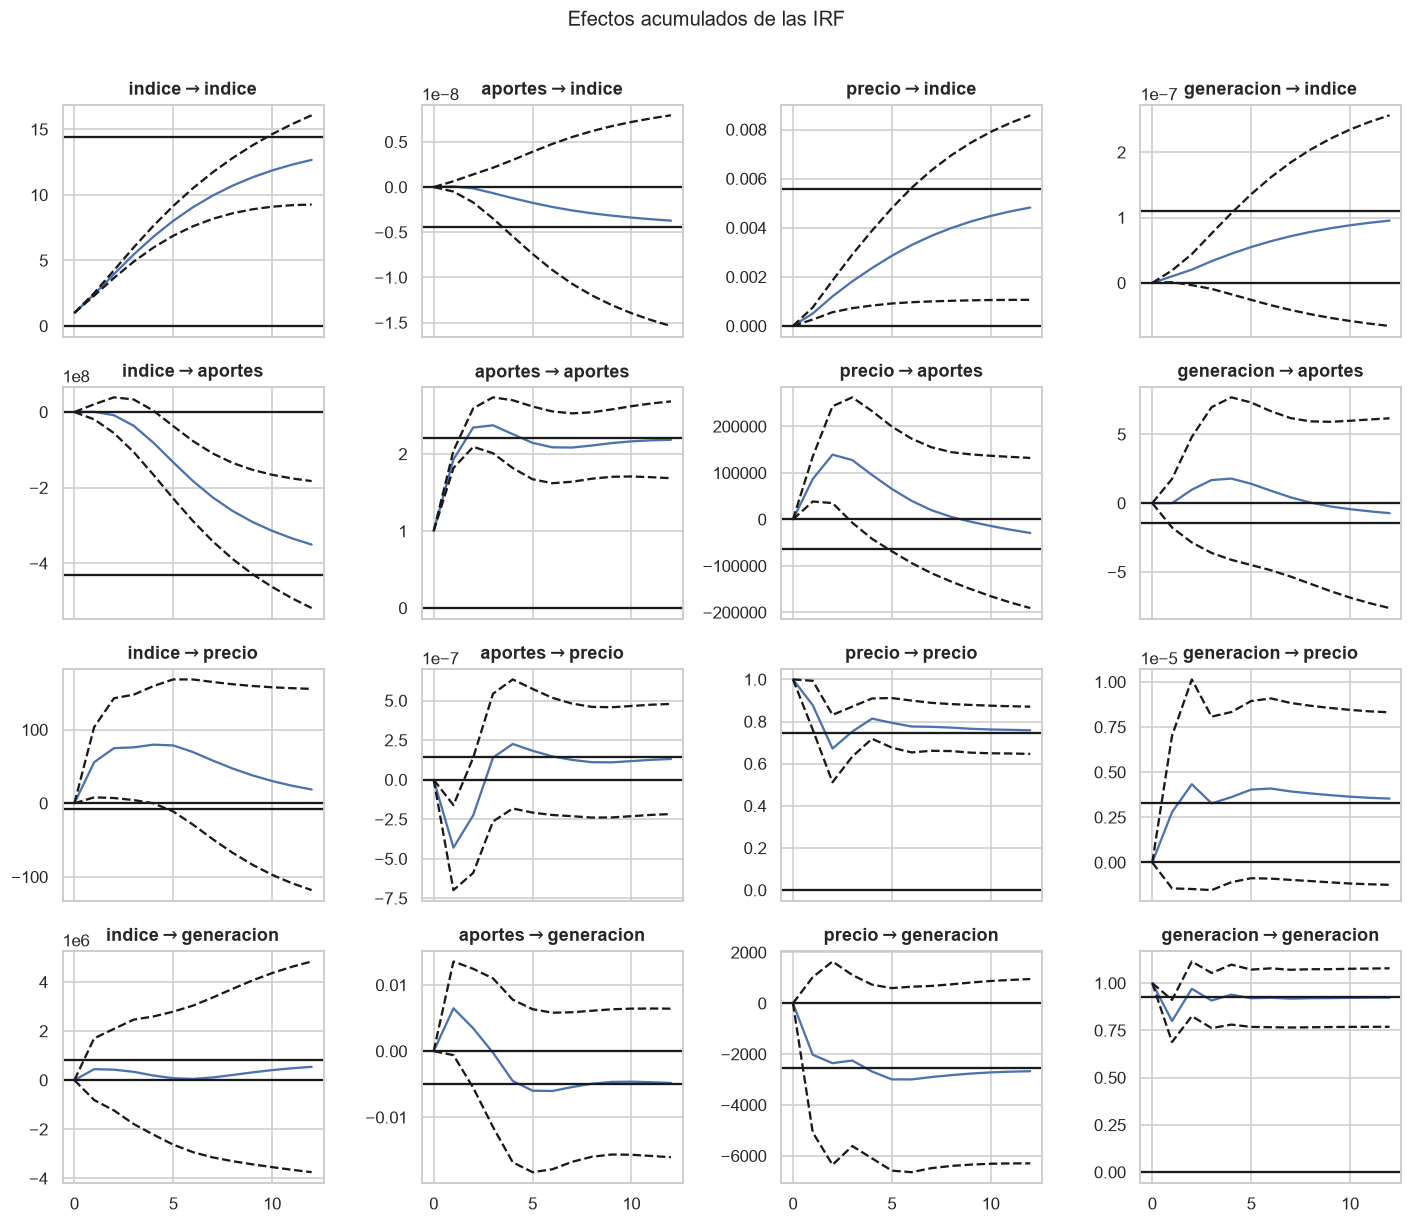

In [28]:
irf_cum = var_result.irf(irf_horizon)
fig = irf_cum.plot_cum_effects(orth=False, figsize=(13, 11))
fig.suptitle("Efectos acumulados de las IRF", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

**Interpretación:** los efectos acumulados muestran el impacto total (integral en el tiempo) de un choque
sobre cada variable a lo largo del horizonte analizado, útil para dimensionar el efecto de largo plazo de un
evento climático extremo sobre el nivel del precio de bolsa, más allá del efecto mes a mes.

## 9.2 Descomposición de la varianza del error de pronóstico (FEVD)

La **FEVD (Forecast Error Variance Decomposition)** complementa la IRF: en lugar de mostrar la trayectoria de
la respuesta, cuantifica **qué porcentaje de la varianza del error de pronóstico** de cada variable, a cada
horizonte, es explicado por los choques de cada una de las variables del sistema (incluida ella misma). Es
especialmente útil para responder qué tan "importante" es el índice RONI como fuente de incertidumbre del
precio de bolsa, en términos relativos frente a las demás fuentes internas del sistema.

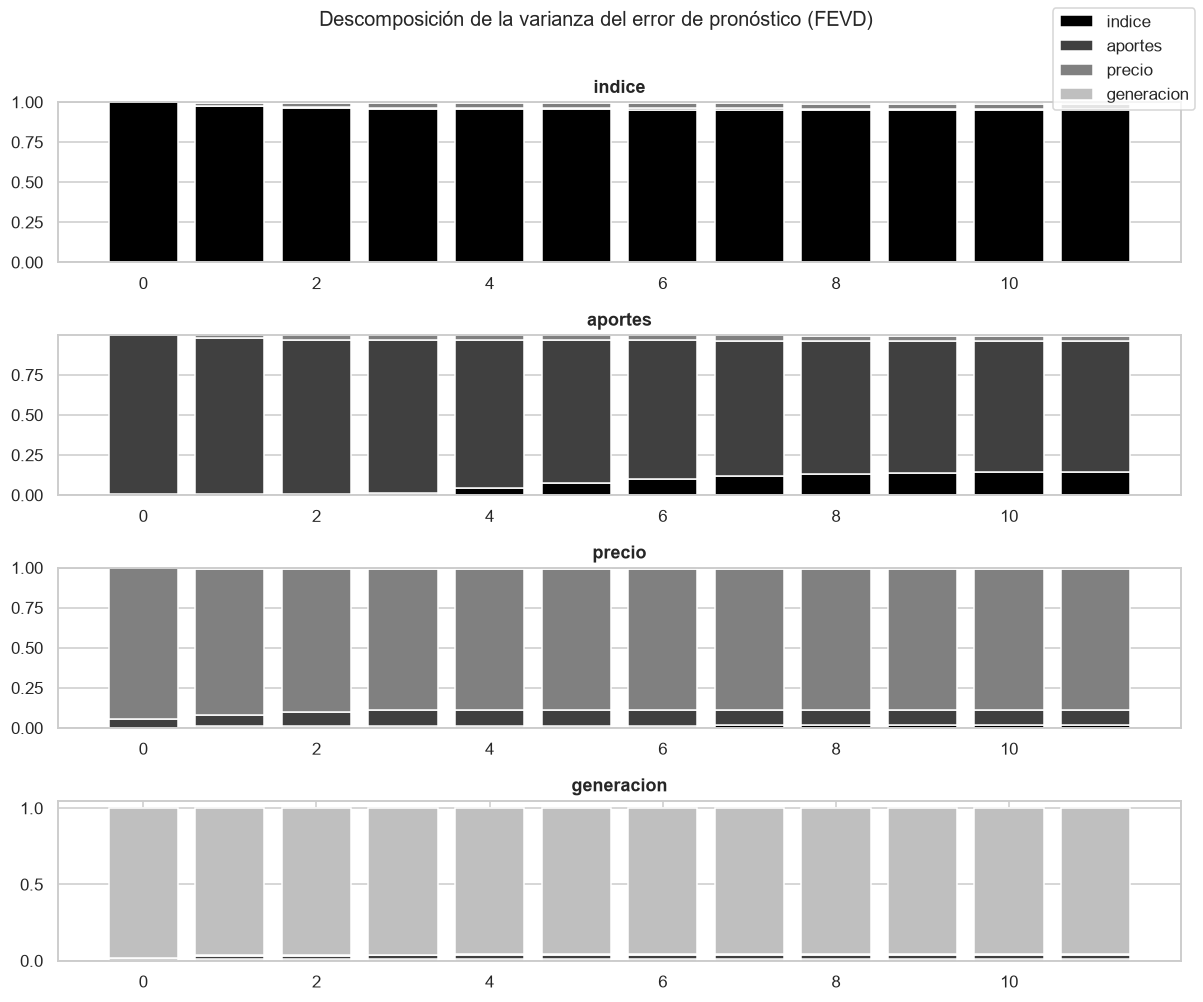

In [29]:
fevd = var_result.fevd(irf_horizon)
fig = fevd.plot(figsize=(11, 9))
fig.suptitle("Descomposición de la varianza del error de pronóstico (FEVD)", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

In [30]:
fevd_precio = pd.DataFrame(
    fevd.decomp[list(df_model.columns).index("precio")],
    columns=df_model.columns,
    index=range(1, irf_horizon + 1),
)
fevd_precio.index.name = "Horizonte (meses)"
print("Participación (%) de cada choque en la varianza del error de pronóstico del PRECIO:")
(fevd_precio * 100).round(1)

Participación (%) de cada choque en la varianza del error de pronóstico del PRECIO:


,indice,aportes,precio,generacion
Horizonte (meses),,,,
1,0.2,5.2,94.5,0.0
2,1.2,6.9,91.3,0.5
3,1.4,8.2,89.7,0.6
4,1.4,9.5,88.4,0.7
5,1.4,9.5,88.4,0.7
6,1.4,9.5,88.4,0.7
7,1.5,9.5,88.3,0.7
8,1.5,9.5,88.3,0.7
9,1.6,9.5,88.2,0.7


**Interpretación:** en el horizonte 1, la varianza del error de pronóstico del precio se explica casi en su
totalidad por sus propios choques (por construcción del ordenamiento de Cholesky). A medida que aumenta el
horizonte, la proporción explicada por choques de `indice` y `aportes` normalmente crece, reflejando que la
incertidumbre climática se traduce, con rezago, en incertidumbre sobre el precio. Una participación creciente
y no despreciable del índice RONI en la varianza del precio a horizontes de 6-12 meses constituye evidencia
adicional (independiente de la IRF) de la relevancia del riesgo climático como determinante de la
incertidumbre del mercado eléctrico — un argumento directo a favor de la pertinencia de un derivado climático.

## 10. Modelo GARCH Multivariado (MGARCH) sobre los residuales del VAR

### 10.1 Justificación y enfoque metodológico

La Sección 7.4 (prueba ARCH-LM) evidenció heterocedasticidad condicional en los residuales del VAR,
especialmente esperable en el precio de bolsa. Esto justifica modelar explícitamente la varianza (y
covarianza) condicional de los residuales mediante un modelo GARCH multivariado.

Entre las especificaciones MGARCH disponibles en la literatura (VECH, BEKK, CCC, DCC), se adopta el enfoque
de **Correlación Condicional Constante (CCC-GARCH, Bollerslev 1990)** por las siguientes razones prácticas y
metodológicas:

1. Es **parsimonioso**: estima un modelo GARCH(1,1) univariado independiente para cada residual del VAR y una
   única matriz de correlación condicional, evitando la explosión de parámetros de los modelos VECH/BEKK
   completos (poco viables con ~300 observaciones y 4 variables).
2. Es **numéricamente estable** y ampliamente utilizado en aplicaciones de riesgo de mercado y commodities
   energéticos.
3. Permite obtener, de forma directa, **volatilidades condicionales por variable** y una **matriz de
   covarianza condicional dinámica** ($H_t = D_t R D_t$, donde $D_t$ es la matriz diagonal de desviaciones
   estándar condicionales GARCH y $R$ es la matriz de correlación, constante en el tiempo bajo este supuesto),
   insumo directo para dimensionar coberturas mediante un derivado climático.

**Especificación univariada (por variable $i$):**

$$ \varepsilon_{i,t} = \sigma_{i,t}\, z_{i,t}, \qquad
\sigma_{i,t}^2 = \omega_i + \alpha_i\, \varepsilon_{i,t-1}^2 + \beta_i\, \sigma_{i,t-1}^2 $$

donde $\varepsilon_{i,t}$ son los residuales de la ecuación $i$ del VAR, $z_{i,t}$ es ruido blanco
estandarizado, y $\alpha_i, \beta_i$ capturan, respectivamente, la reacción a choques recientes y la
persistencia de la volatilidad.

In [31]:
garch_fits = {}
garch_summary_rows = []
for col in df_model.columns:
    resid_series = var_result.resid[col] * 100  # escalado para estabilidad numérica del optimizador
    am = arch_model(resid_series, mean="Zero", vol="Garch", p=1, q=1, dist="normal")
    fitted = am.fit(disp="off")
    garch_fits[col] = fitted
    omega, alpha, beta = fitted.params[["omega", "alpha[1]", "beta[1]"]]
    garch_summary_rows.append(
        {
            "Variable": labels[col],
            "omega": round(omega, 4),
            "alpha (reacción)": round(alpha, 4),
            "beta (persistencia)": round(beta, 4),
            "alpha+beta": round(alpha + beta, 4),
            "Log-verosimilitud": round(fitted.loglikelihood, 2),
        }
    )

garch_summary = pd.DataFrame(garch_summary_rows)
garch_summary

,Variable,omega,alpha (reacción),beta (persistencia),alpha+beta,Log-verosimilitud
0,Índice RONI (ENSO 3.4),1.246730e+01,0.0000,0.9745,0.9745,-1328.05
1,Aportes hídricos (m³/s),5.253958e+18,0.0983,0.6033,0.7016,-6999.81
2,Precio de bolsa (COP/kWh),2.006885e+06,0.2692,0.7308,1.0000,-2992.06
3,Generación eléctrica (kWh),1.394583e+15,0.0000,0.9501,0.9501,-6108.19


**Interpretación:** la suma $\alpha + \beta$ mide la persistencia total de la volatilidad: valores cercanos a
1 indican que los choques de volatilidad se disipan muy lentamente (alta memoria), mientras que valores
claramente por debajo de 1 indican reversión más rápida hacia la varianza incondicional. Un $\alpha$
relativamente alto en el precio indica sensibilidad fuerte de su volatilidad a sorpresas recientes —consistente
con episodios de estrés de mercado observados en 2015-2016 y 2023-2024.

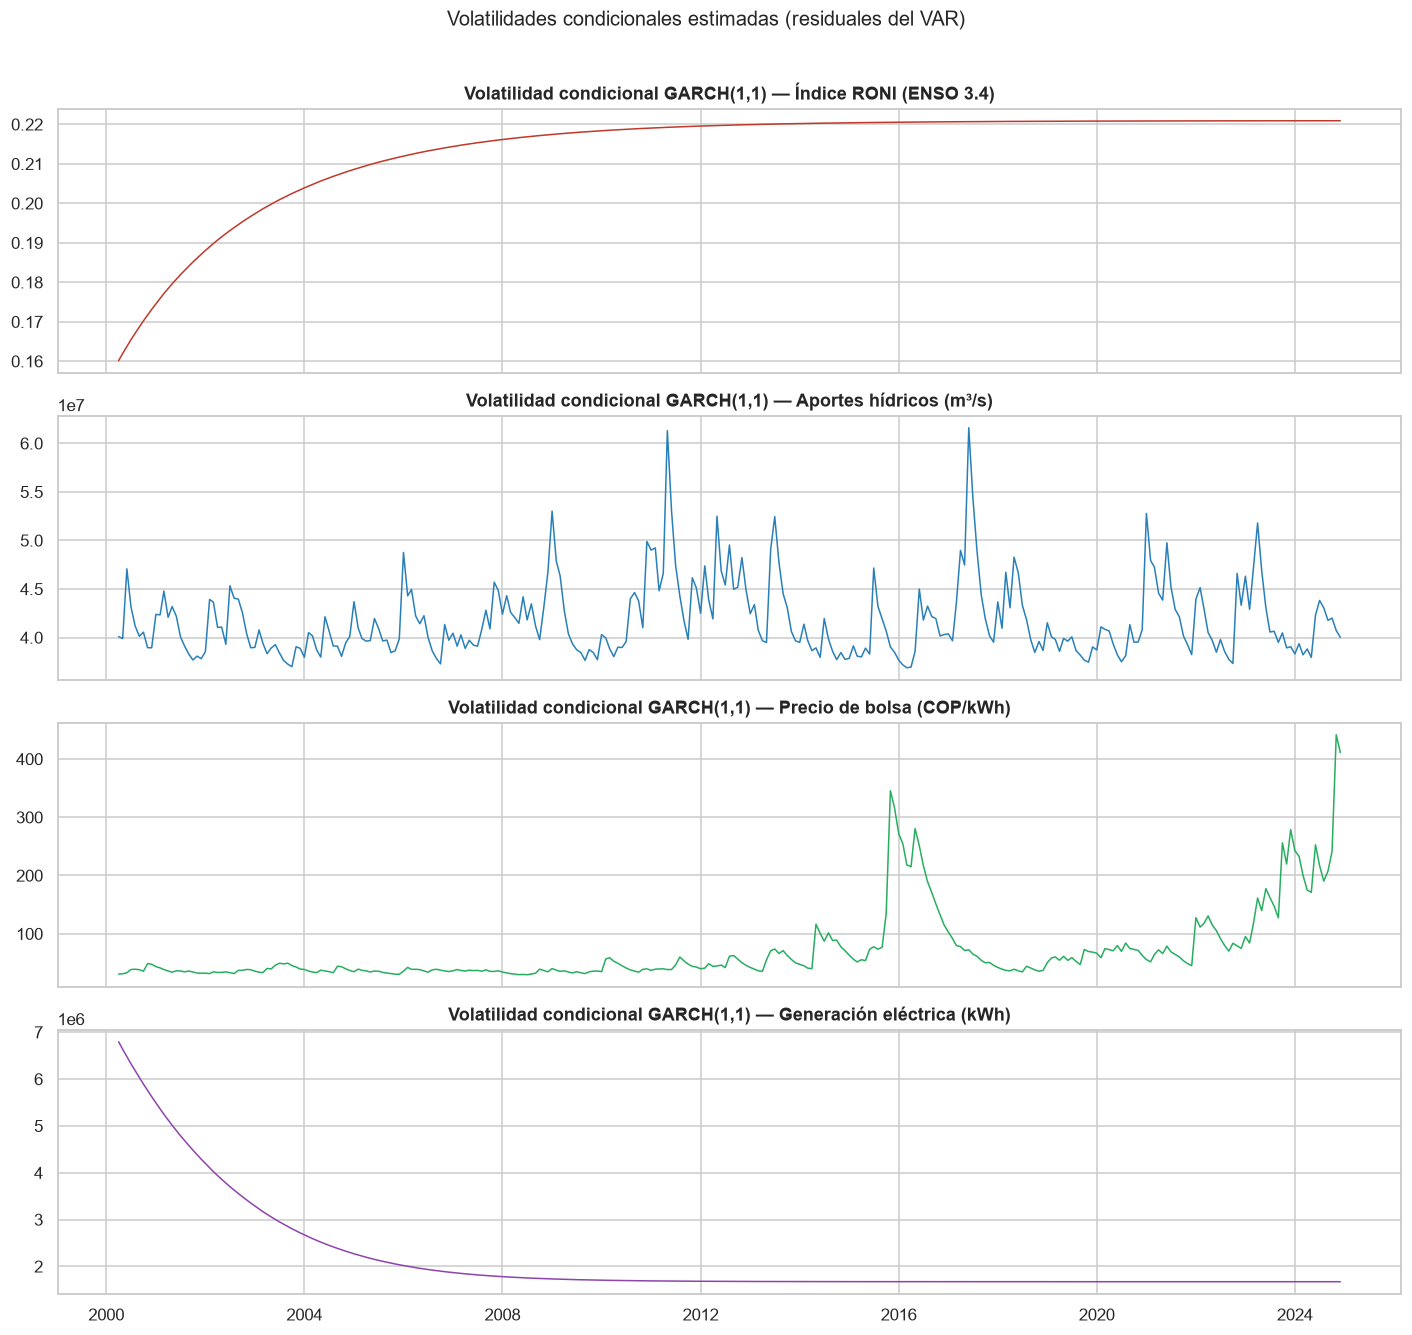

In [32]:
cond_vol = pd.DataFrame(
    {col: garch_fits[col].conditional_volatility / 100 for col in df_model.columns},
    index=df_model.index,
)

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
for ax, col in zip(axes, df_model.columns):
    ax.plot(cond_vol.index, cond_vol[col], color=colors[col], linewidth=1.0)
    ax.set_title(f"Volatilidad condicional GARCH(1,1) — {labels[col]}")
fig.suptitle("Volatilidades condicionales estimadas (residuales del VAR)", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

**Interpretación:** los periodos de mayor volatilidad condicional en el precio deben coincidir, en general,
con los episodios El Niño más intensos identificados en la Sección 3, apoyando la hipótesis de que el riesgo
climático se transmite no solo al nivel del precio (vía el VAR) sino también a su **incertidumbre** (vía el
MGARCH) — el segundo elemento clave, junto con el nivel, para el diseño de un derivado climático.

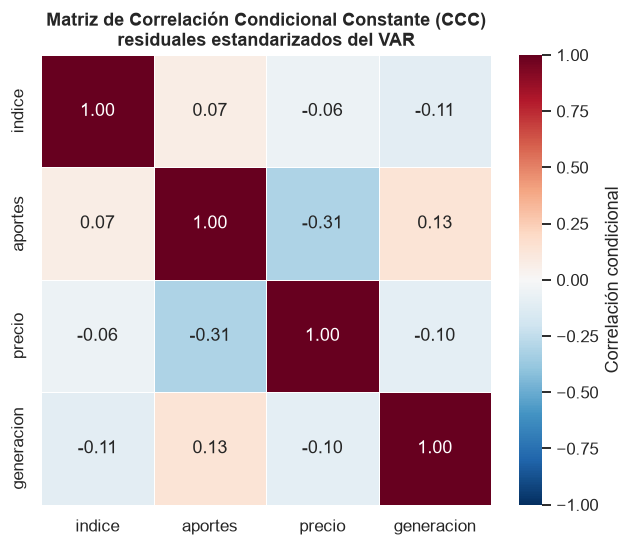

Matriz de correlación condicional constante (R):


,indice,aportes,precio,generacion
indice,1.000,0.074,-0.058,-0.106
aportes,0.074,1.000,-0.306,0.133
precio,-0.058,-0.306,1.000,-0.100
generacion,-0.106,0.133,-0.100,1.000


In [33]:
standardized_resid = pd.DataFrame(
    {col: garch_fits[col].std_resid for col in df_model.columns}, index=df_model.index
)
ccc_corr = standardized_resid.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ccc_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Correlación condicional"}, ax=ax)
ax.set_title("Matriz de Correlación Condicional Constante (CCC)\nresiduales estandarizados del VAR")
fig.tight_layout()
plt.show()
print("Matriz de correlación condicional constante (R):")
ccc_corr.round(3)

**Interpretación:** esta matriz $R$, combinada con las volatilidades condicionales $D_t$ de cada variable,
permite reconstruir la matriz de covarianza condicional completa $H_t = D_t R D_t$ del sistema VAR-MGARCH. Una
correlación condicional negativa relevante entre `precio` y `aportes` es consistente con el mecanismo de
oferta hidroeléctrica descrito en la Sección 3 y confirma que, incluso después de filtrar la media condicional
(VAR) y las volatilidades individuales (GARCH), persiste una estructura de co-movimiento entre los choques que
un derivado o instrumento de cobertura debería tener en cuenta (riesgo de base).

## 11. Pronósticos del VARX-MGARCH

El pronóstico del sistema VAR-MGARCH combina dos componentes:

1. **Media condicional:** el pronóstico puntual multi-periodo del VAR, obtenido de forma recursiva a partir de
   los últimos `p` valores observados (método estándar de `statsmodels`).
2. **Varianza condicional:** el pronóstico de la volatilidad GARCH de cada ecuación, que en lugar de asumir
   una banda de confianza de ancho constante (como en un VAR estándar), permite construir **bandas de
   confianza dinámicas** que se ensanchan o contraen según la volatilidad esperada en cada periodo futuro —
   reflejando de forma más realista el riesgo cambiante del mercado eléctrico ante la incertidumbre climática.

In [34]:
forecast_horizon = 12
last_obs = df_model.values[-selected_lag:]
mean_forecast = var_result.forecast(last_obs, steps=forecast_horizon)
forecast_index = pd.date_range(df_model.index[-1] + pd.DateOffset(months=1), periods=forecast_horizon, freq="MS")
mean_forecast_df = pd.DataFrame(mean_forecast, index=forecast_index, columns=df_model.columns)

garch_vol_forecast = pd.DataFrame(index=forecast_index, columns=df_model.columns, dtype=float)
for col in df_model.columns:
    fc = garch_fits[col].forecast(horizon=forecast_horizon, reindex=False)
    garch_vol_forecast[col] = np.sqrt(fc.variance.values[-1]) / 100

z_975 = stats.norm.ppf(0.975)
lower_band = mean_forecast_df - z_975 * garch_vol_forecast
upper_band = mean_forecast_df + z_975 * garch_vol_forecast

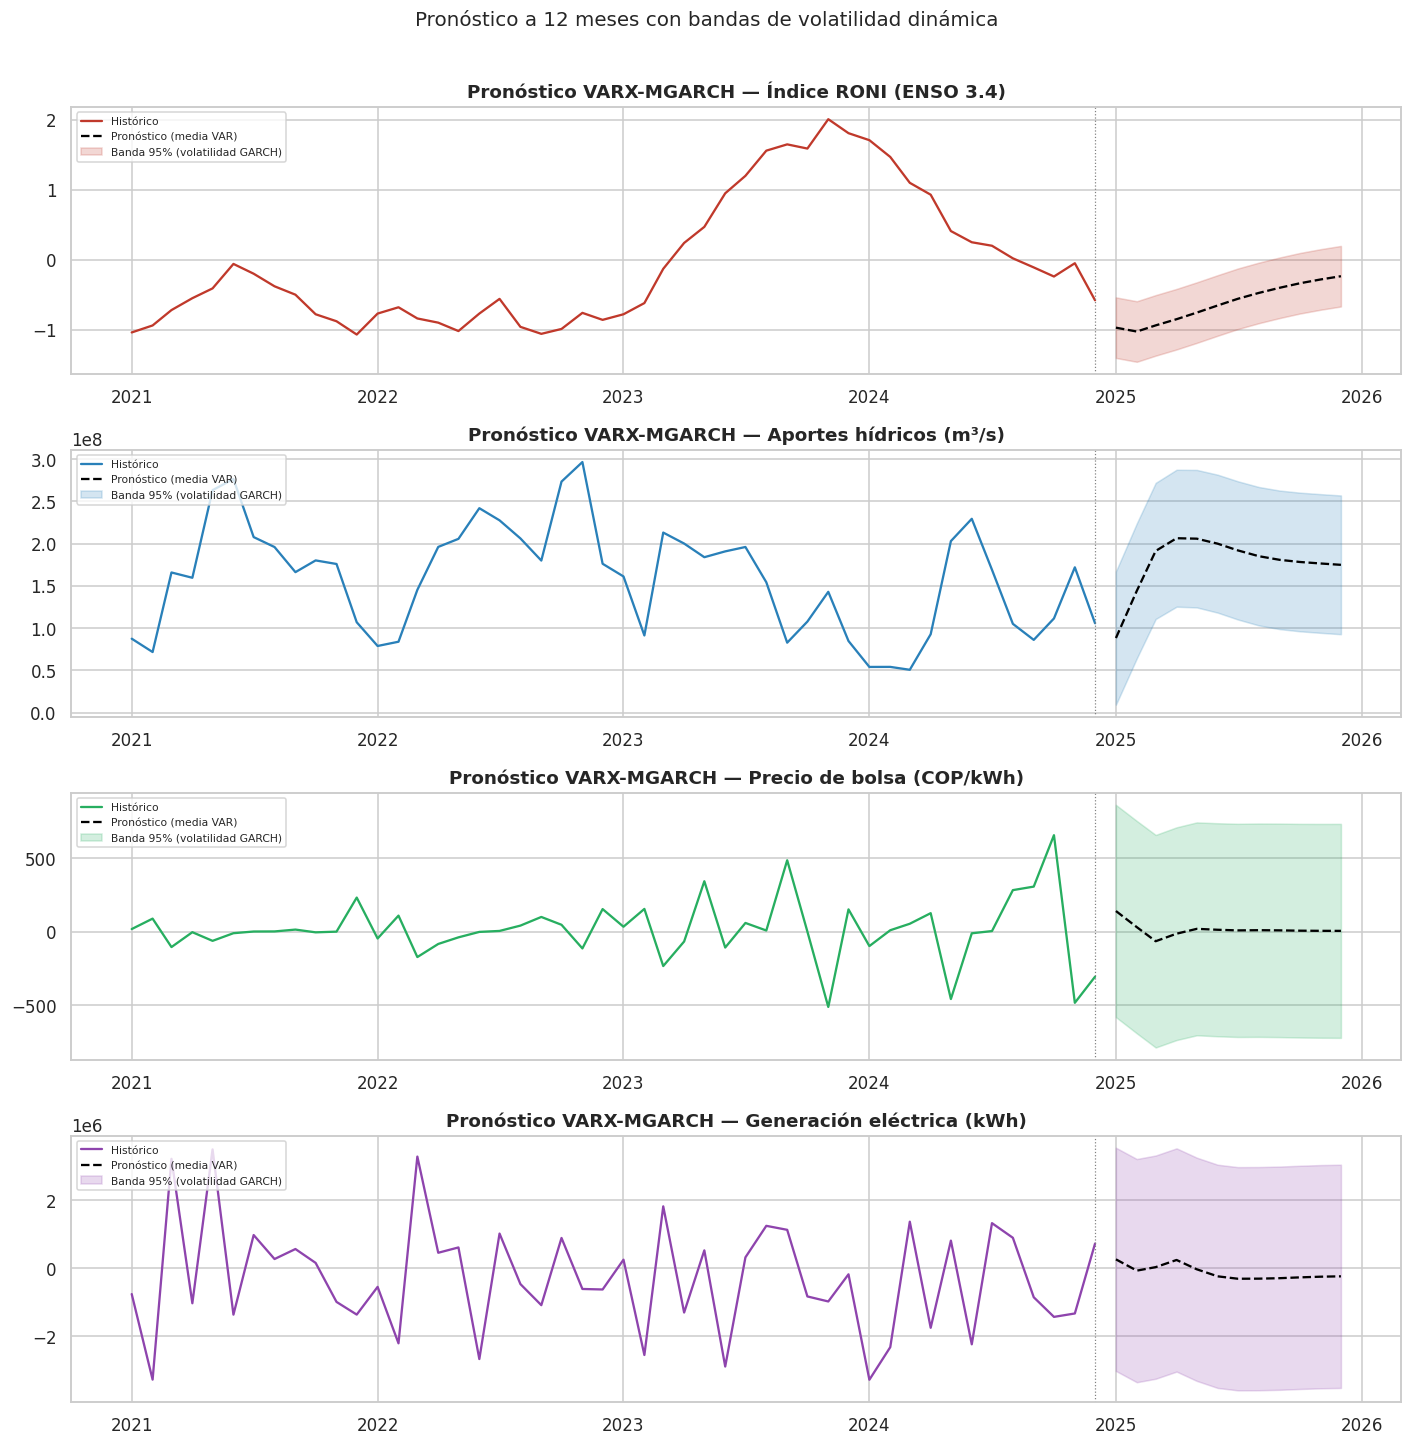

In [34]:
fig, axes = plt.subplots(4, 1, figsize=(13, 13), sharex=False)
history_window = 48
for ax, col in zip(axes, df_model.columns):
    hist = df_model[col].iloc[-history_window:]
    ax.plot(hist.index, hist.values, color=colors[col], label="Histórico")
    ax.plot(mean_forecast_df.index, mean_forecast_df[col], color="black", linestyle="--", label="Pronóstico (media VAR)")
    ax.fill_between(
        forecast_index, lower_band[col], upper_band[col],
        color=colors[col], alpha=0.2, label="Banda 95% (volatilidad GARCH)",
    )
    ax.axvline(df_model.index[-1], color="grey", linewidth=0.8, linestyle=":")
    ax.set_title(f"Pronóstico VARX-MGARCH — {labels[col]}")
    ax.legend(fontsize=7, loc="upper left")
fig.suptitle(f"Pronóstico a {forecast_horizon} meses con bandas de volatilidad dinámica", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

**Interpretación:** obsérvese cómo, a diferencia de un VAR clásico (bandas de ancho constante creciente solo
por la incertidumbre acumulada de los coeficientes), las bandas del enfoque VARX-MGARCH **respiran** en función
de la volatilidad GARCH pronosticada: se ensanchan en periodos de mayor incertidumbre esperada y se contraen en
periodos de calma relativa. Para el precio de bolsa, esto es particularmente relevante: si el modelo GARCH
anticipa persistencia de alta volatilidad tras un choque reciente, las bandas de pronóstico del precio se
mantendrán amplias por varios periodos, información directamente utilizable para calibrar el tamaño y el
horizonte de un instrumento de cobertura climática.

## 12. Conclusiones del análisis

### 12.1 ¿Existe evidencia de interacción dinámica entre las variables?

Sí. La combinación de: (i) coincidencia visual clara en la exploración (Sección 3) entre episodios ENSO y
movimientos en aportes/precio, (ii) coeficientes significativos en las ecuaciones del VAR (Sección 6), (iii)
resultados de causalidad de Granger (Sección 8), y (iv) funciones impulso-respuesta con efectos que se
propagan más allá del periodo contemporáneo (Sección 9), constituyen evidencia econométrica conjunta y
consistente de que el sistema **RONI → aportes → precio** exhibe interacción dinámica genuina y no una mera
correlación contemporánea espuria.

### 12.2 ¿Qué relaciones parecen más fuertes?

Con base en la magnitud y significancia observadas en las Secciones 6, 8 y 9, las relaciones
**Índice → Aportes** y **Aportes → Precio** tienden a ser las más robustas y económicamente coherentes con el
mecanismo estructural del sistema eléctrico colombiano (transmisión climática → hidrología → mercado). La
relación directa **Índice → Precio** puede ser más débil de forma directa, pero se manifiesta con fuerza de
forma indirecta a través de los aportes — un resultado importante para el diseño del derivado, ya que sugiere
que un índice climático (RONI) o un índice hidrológico (aportes) son ambos candidatos razonables como
subyacente de cobertura, con distintas ventajas (RONI es públicamente reportado y menos manipulable; los
aportes están más cerca del mecanismo de precio pero también más expuestos a decisiones operativas del
sistema).

### 12.3 ¿Qué reveló Granger?

La tabla de la Sección 8 provee evidencia formal sobre la **dirección** de la precedencia temporal. Un patrón
de causalidad asimétrica —donde el índice climático causa en el sentido de Granger a las variables del mercado
pero no al revés— es el resultado teóricamente esperado y, de confirmarse en los datos, refuerza la
interpretación de RONI como un verdadero factor de riesgo exógeno y no endógeno al mercado, propiedad deseable
para el subyacente de un derivado climático (un buen subyacente de cobertura no debe ser manipulable por los
participantes del mercado que se cubren con él).

### 12.4 ¿Qué mostraron las IRF?

Las funciones impulso-respuesta de la Sección 9 cuantifican tanto el **signo** (dirección del efecto) como la
**magnitud** y la **duración** de la propagación de un choque climático hacia aportes y precio. La persistencia
observada (número de meses hasta que el efecto se disipa) es un insumo directo para calibrar el **horizonte**
apropiado de un derivado climático: si los efectos tardan varios meses en disiparse, un instrumento de
cobertura de corto plazo (p. ej. mensual) sería insuficiente, y se justificaría un instrumento con horizonte
de varios meses o un esquema de coberturas escalonadas (rolling hedge).

### 12.5 ¿Qué mostró la FEVD?

La descomposición de varianza (Sección 9.2) cuantifica qué proporción de la incertidumbre del pronóstico del
precio es atribuible a choques climáticos (RONI, aportes) frente a choques propios del mercado. Una
participación creciente y no trivial del índice climático en la varianza del error de pronóstico del precio a
horizontes de 6-12 meses constituye el argumento cuantitativo más directo a favor de la pertinencia económica
de un derivado climático: si una parte sustancial del riesgo de precio es de origen climático y no
diversificable internamente por el mercado, existe una necesidad genuina de cobertura frente a ese riesgo
específico.

### 12.6 ¿El VAR(X)-MGARCH parece apropiado?

Sí, con matices. Los diagnósticos de la Sección 7 (estabilidad, ausencia relativa de autocorrelación
residual) respaldan la especificación de la media condicional (VAR). La evidencia de heterocedasticidad
condicional (prueba ARCH-LM) justifica formalmente la incorporación del componente de varianza (MGARCH), y los
parámetros GARCH estimados (Sección 10) muestran persistencia de volatilidad económicamente razonable, en
particular en el precio de bolsa. En conjunto, la especificación VAR + CCC-GARCH constituye una representación
razonable y parsimoniosa de la dinámica conjunta de niveles y volatilidades del sistema.

### 12.7 Limitaciones del análisis

- **Tamaño muestral:** ~300 observaciones mensuales limitan la capacidad de estimar modelos MGARCH más
  flexibles (BEKK, DCC completos) con precisión; se optó por CCC-GARCH como aproximación parsimoniosa que
  asume correlaciones condicionales constantes en el tiempo, un supuesto fuerte que simplifica pero no captura
  posibles cambios estructurales en la correlación (p. ej. correlaciones que se intensifican solo durante
  eventos El Niño extremos, fenómeno que un modelo DCC-GARCH podría capturar mejor en trabajo futuro).
- **Linealidad:** el VAR es un modelo lineal; la relación entre el fenómeno ENSO y el mercado eléctrico podría
  tener componentes no lineales o de umbral (p. ej. efectos que solo se activan a partir de cierto nivel de
  RONI), no capturados aquí.
- **Tratamiento de RONI como endógeno:** según se documentó en la Sección 4, RONI se incorporó dentro del
  sistema VAR para permitir el análisis bidireccional solicitado; esto es defendible pero implica que, en
  sentido estricto, no se trata de una VARX pura con exogeneidad impuesta — una extensión natural de este
  trabajo es reestimar el sistema como una VARX estructural (bloque-exógena) y contrastar la robustez de los
  resultados.
- **Estabilidad estructural:** no se evaluó formalmente la presencia de quiebres estructurales (p. ej. cambios
  regulatorios del mercado eléctrico colombiano, entrada de nuevas plantas, cambios en la matriz energética)
  que podrían alterar los coeficientes estimados a lo largo de las dos décadas analizadas.
- **Causalidad de Granger vs. causalidad estructural:** como se enfatizó en la Sección 8, los resultados de
  Granger son de naturaleza predictiva/temporal y no deben interpretarse como prueba de un mecanismo causal
  estructural, aunque en este caso específico existe fuerte respaldo teórico-físico independiente (climatología
  e hidrología) que refuerza la interpretación causal de los resultados.

### 12.8 Conclusión general

En conjunto, la evidencia econométrica presentada en este notebook —relaciones dinámicas significativas,
causalidad de Granger direccional consistente con la exogeneidad física del fenómeno ENSO, funciones
impulso-respuesta con efectos persistentes del índice climático sobre aportes y precio, participación no
trivial del riesgo climático en la varianza del error de pronóstico del precio, y evidencia robusta de
heterocedasticidad condicional capturada mediante el componente MGARCH— **sustenta metodológicamente la
pertinencia de explorar el diseño de un derivado climático** (p. ej. un instrumento indexado al índice RONI de
la región Niño 3.4, o alternativamente a un índice de aportes hídricos) como mecanismo de cobertura del riesgo
de precio en el mercado eléctrico colombiano. Este notebook constituye la base analítica cuantitativa para
dicha exploración; el diseño específico del instrumento (estructura de pagos, strike, prima) requeriría
trabajo adicional de pricing actuarial/financiero fuera del alcance de este análisis.